<a href="https://colab.research.google.com/github/kmk0909/2026-BDA/blob/main/code/10w_data_vis_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##9.3바이올린과 상관관계 시각화

In [1]:
!pip install koreanize-matplotlib
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 25.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

In [3]:
!pip install pydataset
from pydataset import data
iris = data('iris')
iris.info()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 34.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=63ea635674360d739ca50513104620873f4ae7d3db462a91bab55b898e5f3993
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset
initiated datasets repo at: /root/.pydataset/
<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [4]:
iris.describe()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
iris.describe(include='all')

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


In [6]:
from IPython.display import display_html
def display_side_by_side(*args):
    """여러 데이터프레임 비교가 쉽게 옆쪽으로 표시한다"""
    html_str=''
    for df in args:
        html_str += df.to_html() + '&nbsp;'*4
    display_html(html_str.replace('table','table style="display:inline"'), raw=True)


In [7]:
from IPython.display import display_html

def display_series_side_by_side(*args, names=None):
    """여러 Series를 옆으로 나란히 표시한다.

    Parameters
    ----------
    *args   : pd.Series 객체들
    names   : 각 Series의 제목 리스트 (생략 시 Series.name 사용)
    """
    html_str = ''
    for i, s in enumerate(args):
        # 제목 결정: names 인자 > Series.name > 인덱스 번호
        if names and i < len(names):
            title = names[i]
        elif s.name is not None:
            title = s.name
        else:
            title = f'Series {i}'

        table_html = s.to_frame(name=title).to_html()
        html_str += table_html + '&nbsp;' * 4

    display_html(
        html_str.replace('table', 'table style="display:inline; vertical-align:top"'),
        raw=True
    )

In [8]:
display_side_by_side(iris.head(), iris.tail())

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
146,6.7,3.0,5.2,2.3,virginica
147,6.3,2.5,5.0,1.9,virginica
148,6.5,3.0,5.2,2.0,virginica
149,6.2,3.4,5.4,2.3,virginica


In [9]:
display_series_side_by_side(iris['Sepal.Length'][:5], iris['Petal.Width'][-5:])

,Sepal.Length
1,5.1
2,4.9
3,4.7
4,4.6
5,5.0
,Petal.Width
146,2.3
147,1.9
148,2.0
149,2.3


In [ ]:
display_side_by_side(iris['Sepal.Length'][:5].to_frame(), iris['Petal.Width'][-5:].to_frame())

,Sepal.Length
1,5.1
2,4.9
3,4.7
4,4.6
5,5.0
,Petal.Width
146,2.3
147,1.9
148,2.0
149,2.3


In [10]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (5, 3)

<Axes: ylabel='Density'>

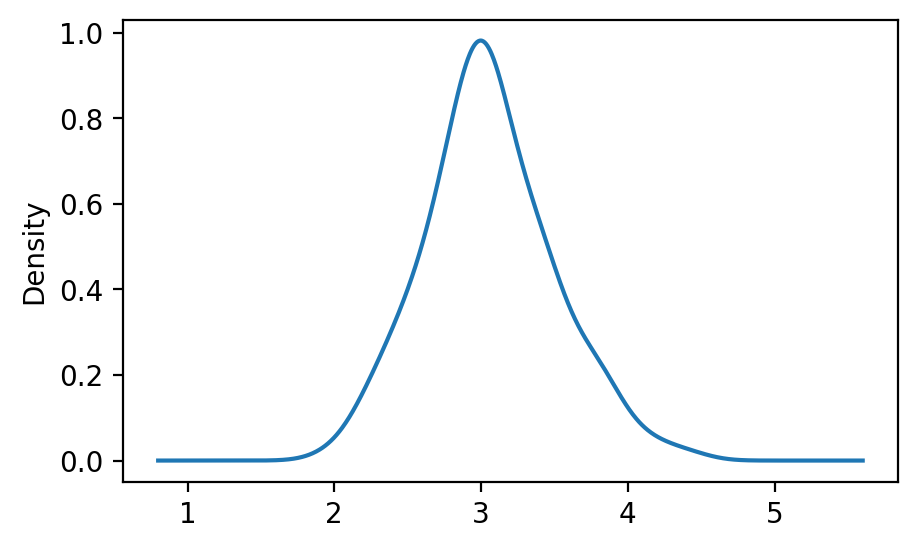

In [11]:
iris['Sepal.Width'].plot.density()

<Axes: ylabel='Density'>

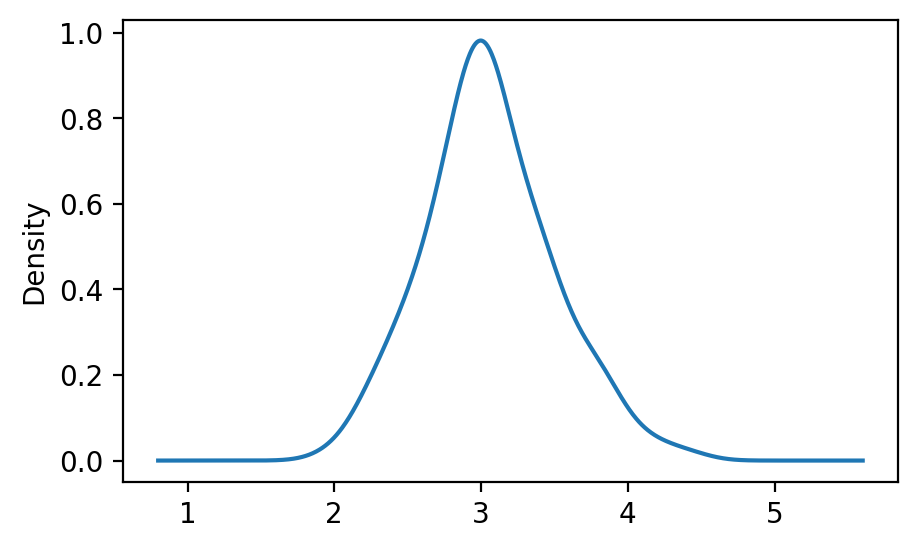

In [12]:
iris['Sepal.Width'].plot.kde()

<Axes: xlabel='Sepal.Width', ylabel='Count'>

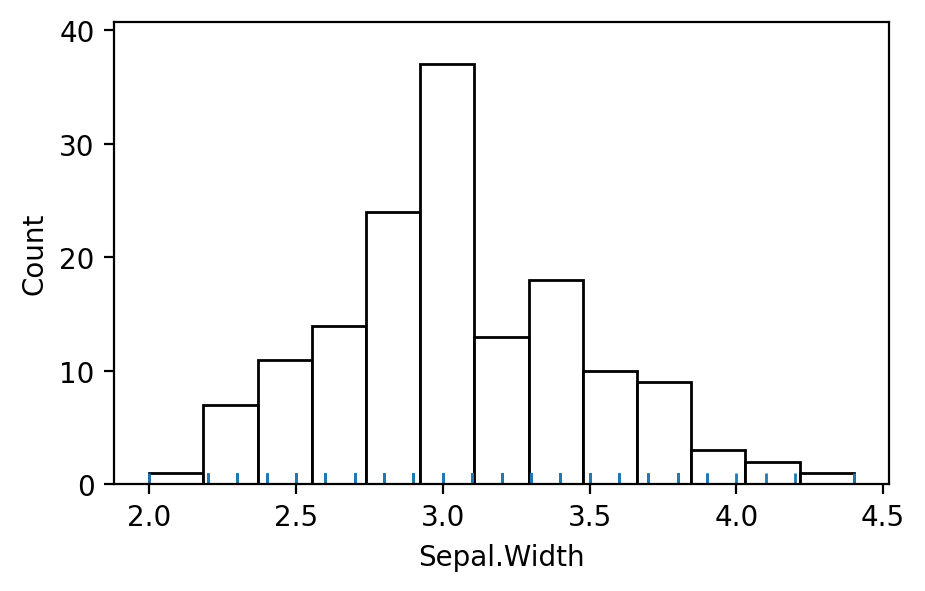

In [13]:
import seaborn as sns
sns.histplot(data=iris, x = iris['Sepal.Width'], color='white')
sns.rugplot(data=iris, x = iris['Sepal.Width'])

<Axes: xlabel='Sepal.Width', ylabel='Count'>

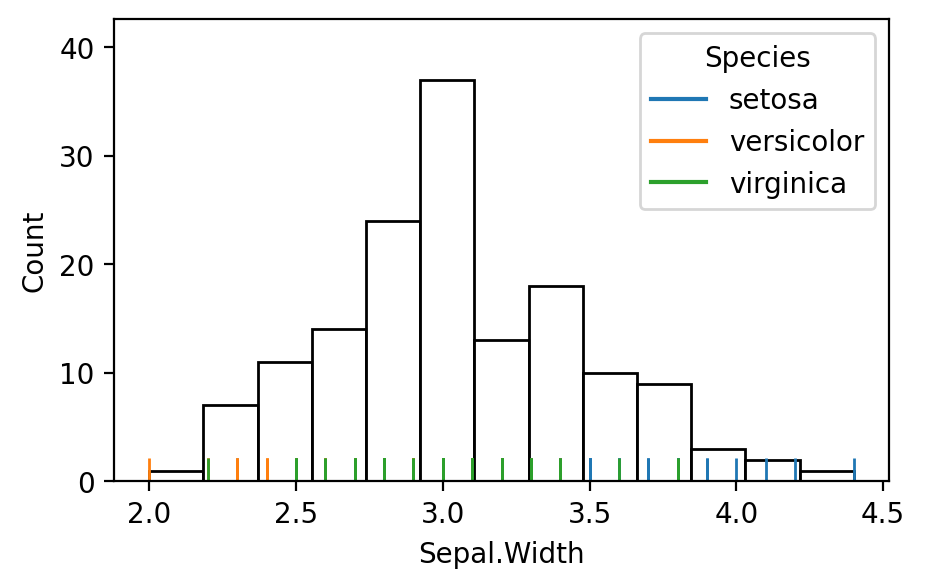

In [14]:
sns.histplot(data=iris, x = iris['Sepal.Width'], color='white')
sns.rugplot(data = iris, x = iris['Sepal.Width'],
height=0.05, hue='Species')

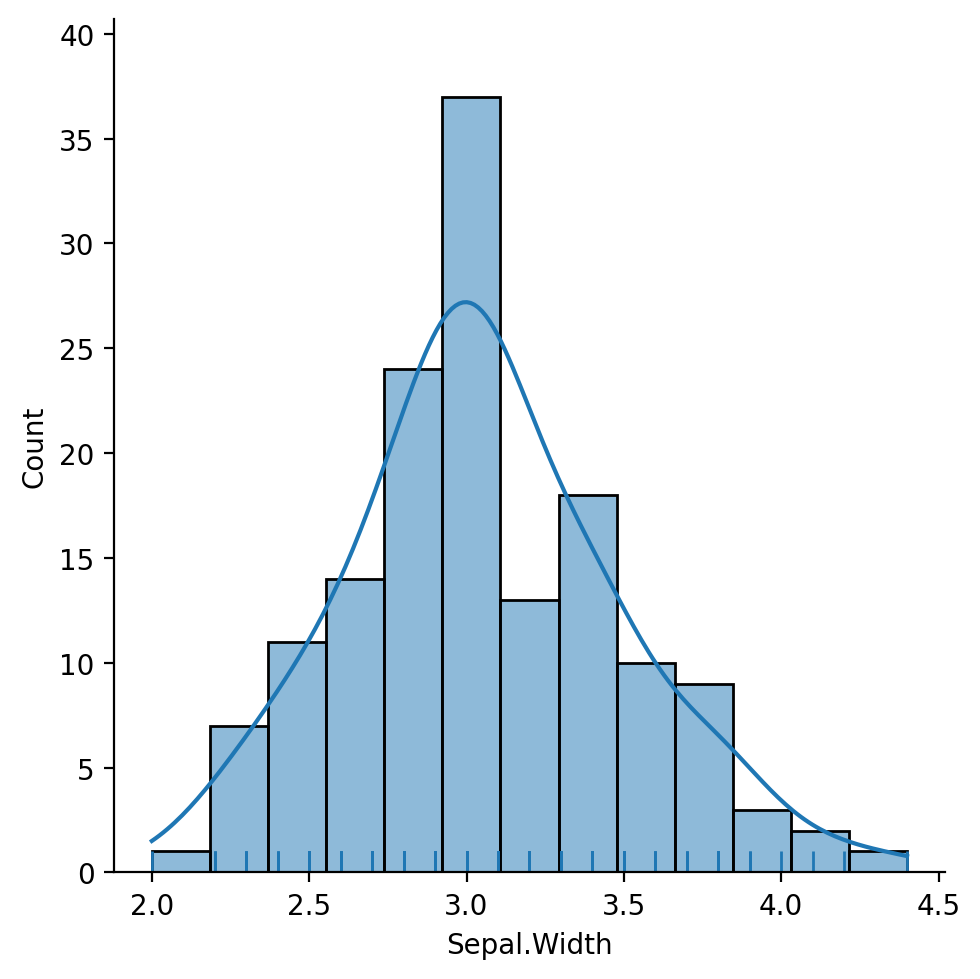

In [15]:
sns.displot(data = iris, x = iris['Sepal.Width'], kde=True, rug=True)

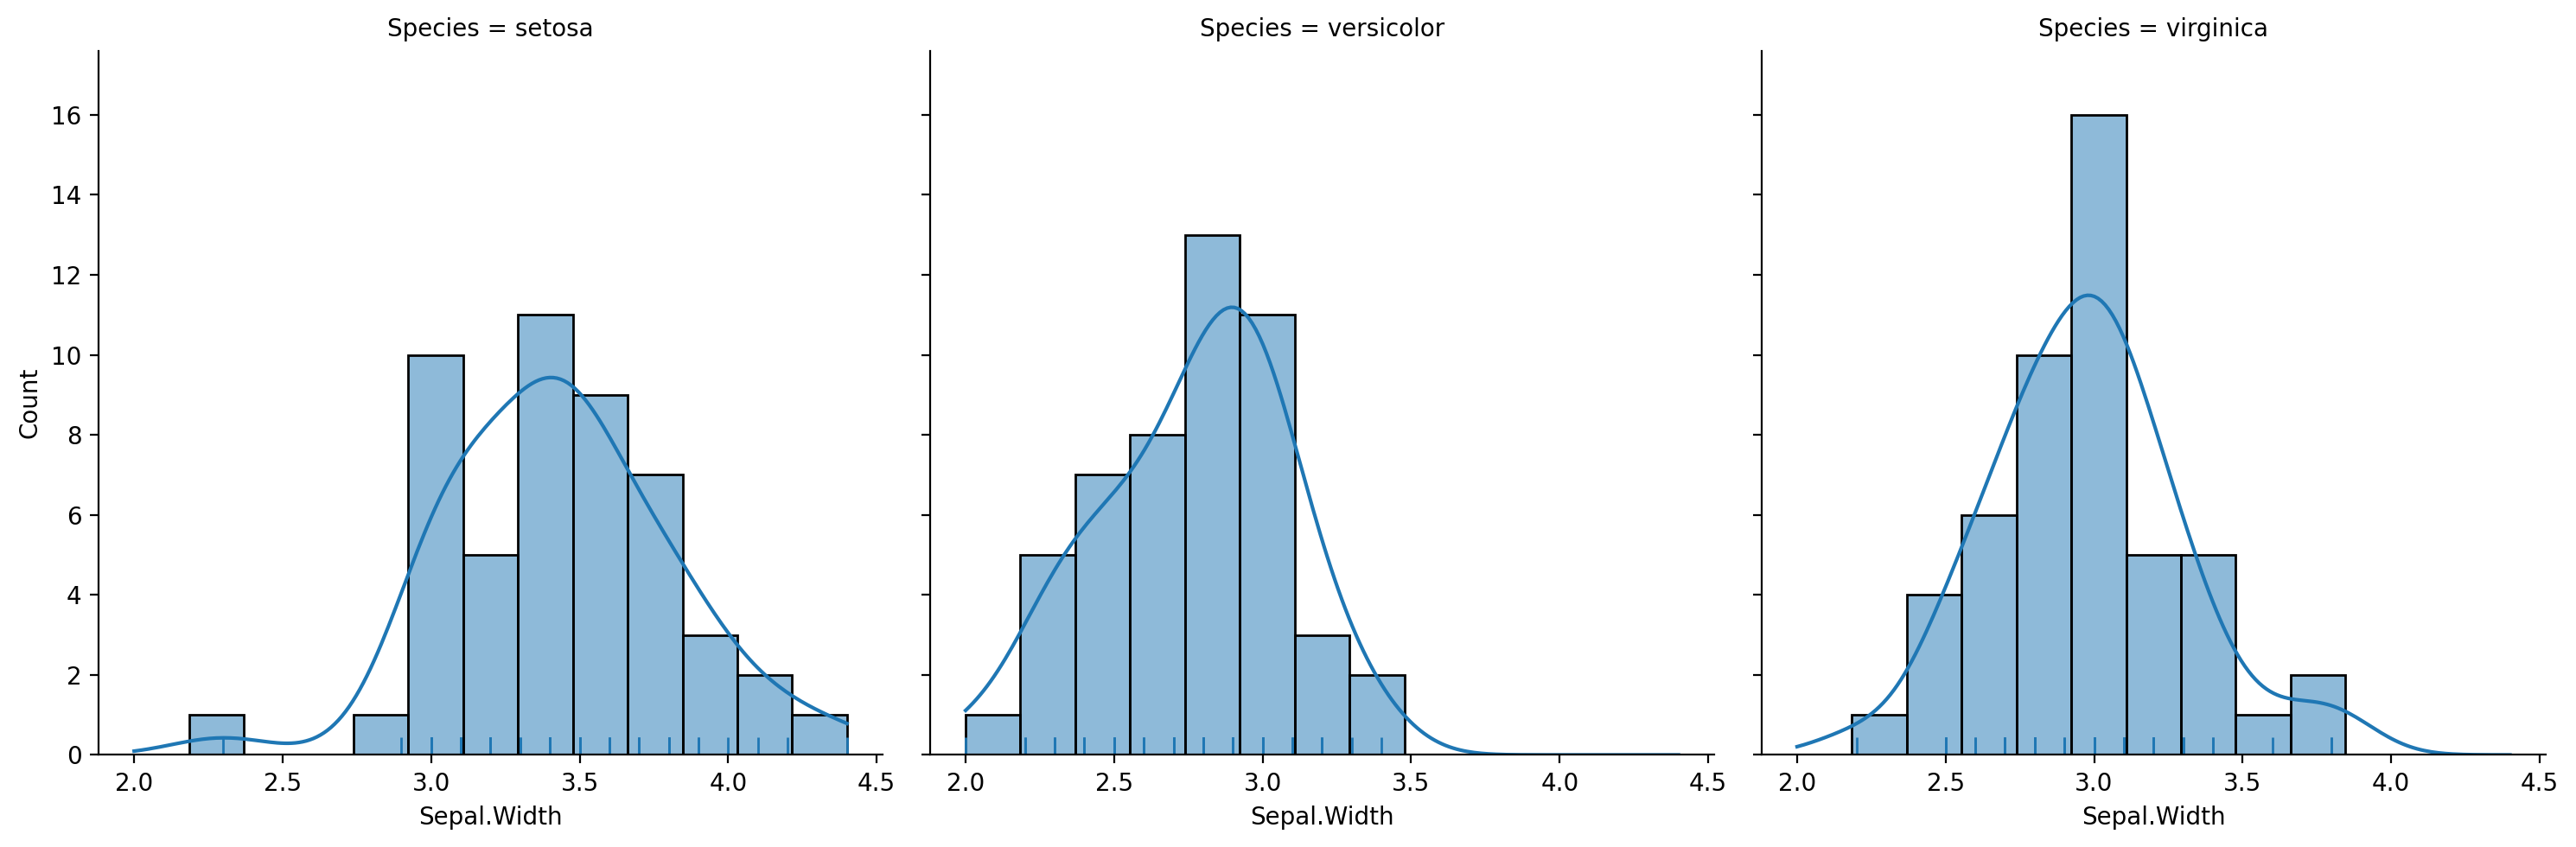

In [16]:
sns.displot(data = iris, x = iris['Sepal.Width'], col="Species", kde=True, rug=True)

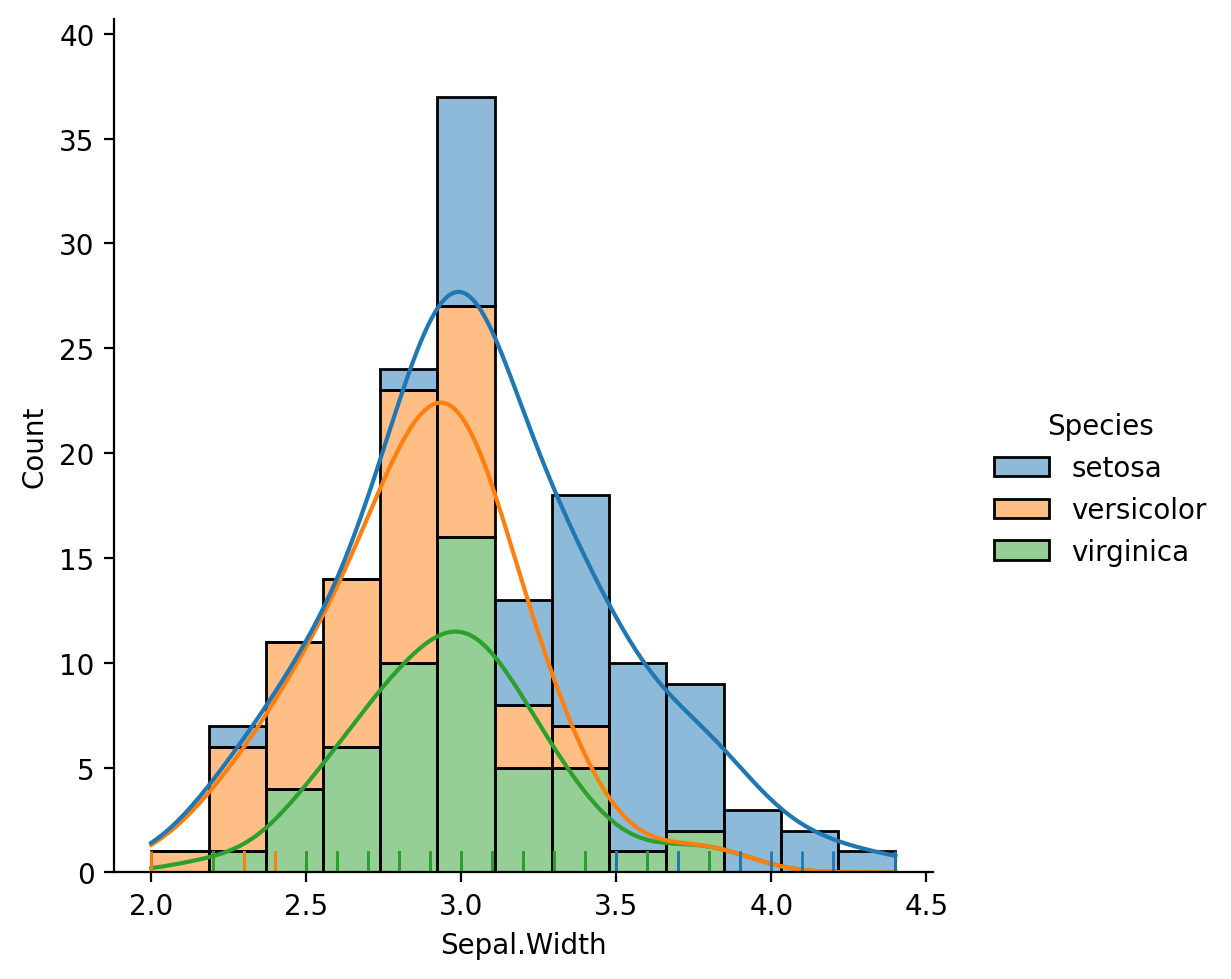

In [18]:
sns.displot(data = iris, x = iris['Sepal.Width'], hue="Species", kde=True, rug=True,multiple="stack")

([<matplotlib.patches.Wedge at 0x793e7f67bbf0>,
 [Text(1.0461621649530053, 0.3399187029582827, 'Oranges'),
  Text(0.33991865722907993, 1.0461621798113232, 'Apples'),
  Text(-1.046162235191088, 0.33991848678762215, 'Bananas'),
  Text(0.33991884014588697, -1.0461621203780394, 'Cherries')])

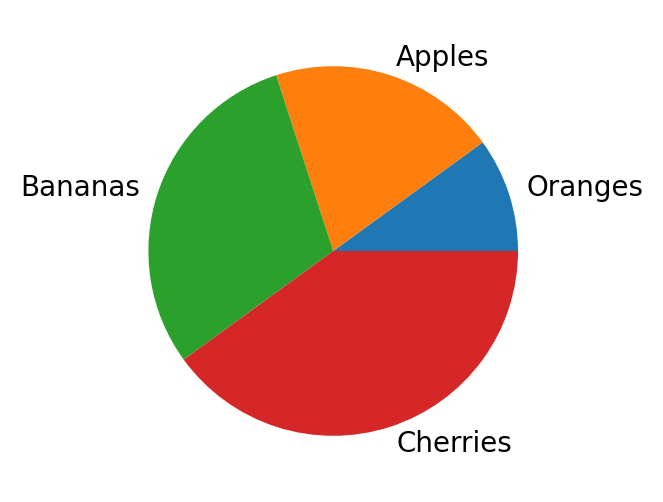

In [19]:
fruits=['Oranges','Apples','Bananas','Cherries']
plt.pie([10,20,30,40],labels=fruits)

In [23]:
from pydataset import data
mtc = data('mtcars')
mtc.cyl.value_counts().sort_index()

,count
cyl,
4,11
6,7
8,14


In [24]:
mtc.cyl.value_counts().sort_index().index

Index([4, 6, 8], dtype='int64', name='cyl')

In [25]:
txt=[str(i)+'기통' for i in mtc.cyl.value_counts().sort_index().index]
txt

['4기통', '6기통', '8기통']

In [27]:
labels=[str(i)+'기어' for i in mtc.gear.value_counts().sort_index().index]
labels

['3기어', '4기어', '5기어']

In [28]:
colors = sns.color_palette('Accent',len(labels))
colors

[(0.4980392156862745, 0.788235294117647, 0.4980392156862745),
 (0.7450980392156863, 0.6823529411764706, 0.8313725490196079),
 (0.9921568627450981, 0.7529411764705882, 0.5254901960784314)]

In [29]:
colors = sns.color_palette('Set1',len(labels))
colors

[(0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
 (0.21568627450980393, 0.49411764705882355, 0.7215686274509804),
 (0.30196078431372547, 0.6862745098039216, 0.2901960784313726)]

In [30]:
colors = sns.color_palette('Set2',7)
colors

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451)]

In [32]:
import koreanize_matplotlib
import matplotlib.pyplot as plt

# Ensure the figsize is set as before
plt.rcParams['figure.figsize'] = (5, 3)

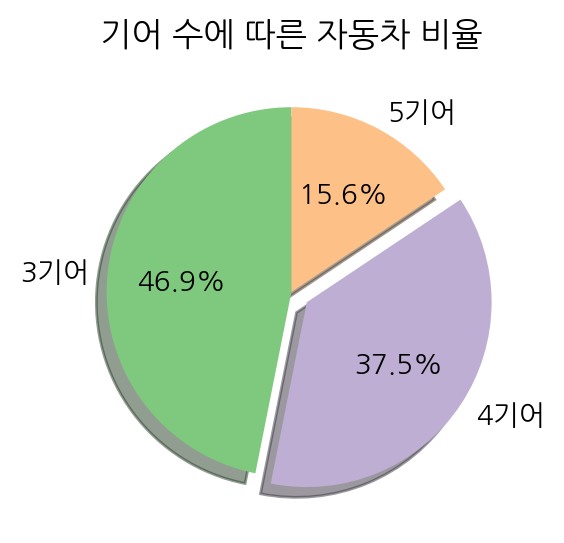

In [33]:
# Regenerate the pie chart with Korean font support
colors = sns.color_palette('Accent',len(labels))
plt.pie(mtc.gear.value_counts().sort_index(),
        colors=colors, explode=[0,.1,0],
        shadow=True, startangle=90,
        autopct='%.1f%%',labels=labels)
plt.title("기어 수에 따른 자동차 비율")
plt.show()

Text(0.5, 1.0, '기통 수에 따른 자동차 비율')

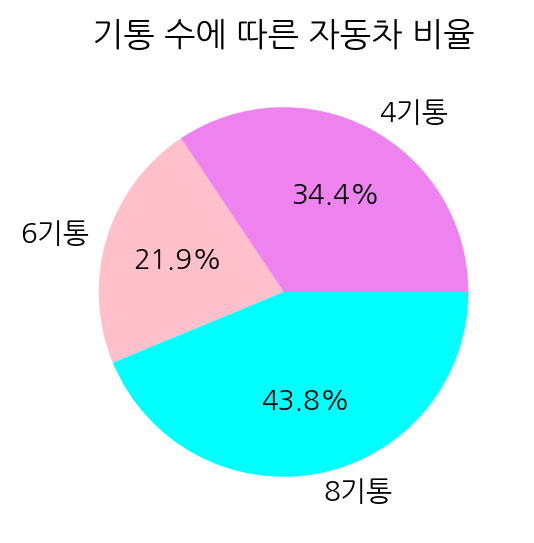

In [34]:
plt.pie(mtc.cyl.value_counts().sort_index(),
        colors=["violet","pink","aqua"],
        autopct='%.1f%%',labels=txt)
plt.title("기통 수에 따른 자동차 비율")

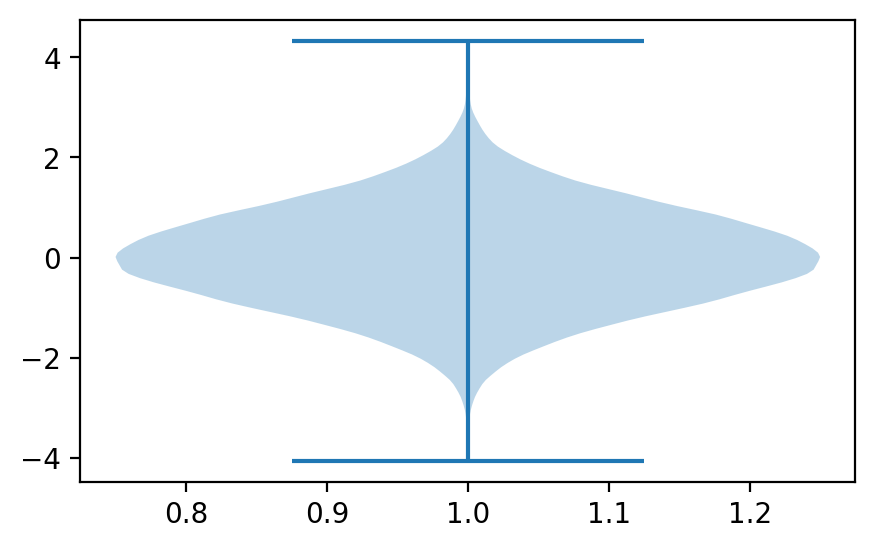

In [ ]:
data = np.random.randn(100000)
plt.violinplot(data)
plt.show()

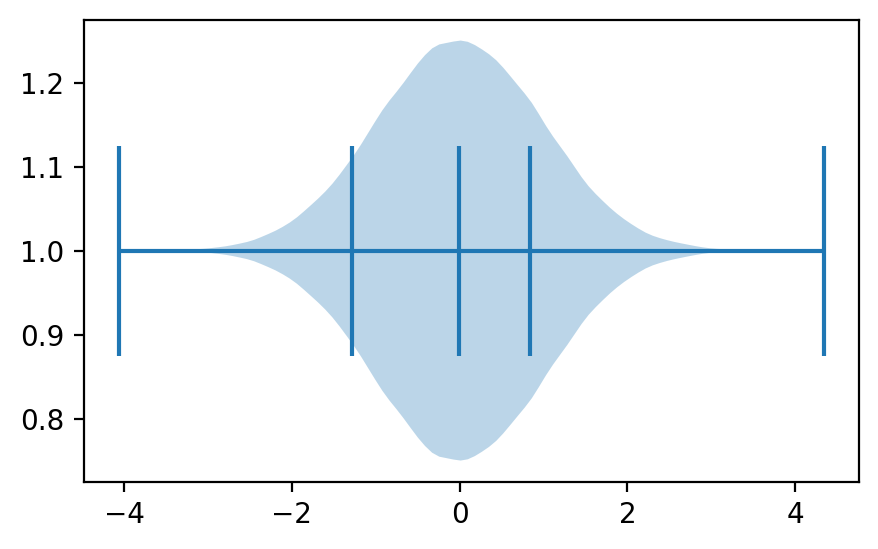

In [ ]:
plt.violinplot(data, vert=False, quantiles=[.1, .5, .8])
plt.show()

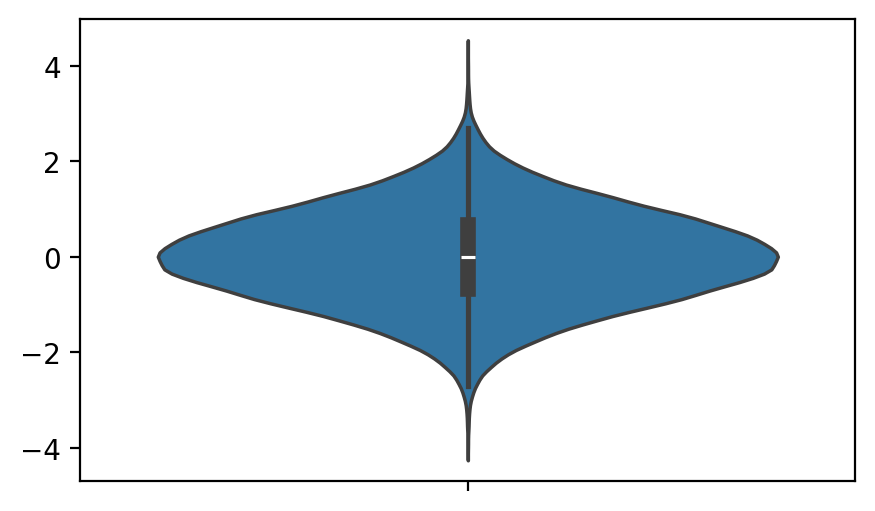

In [ ]:
import seaborn as sns
sns.violinplot(data)
plt.show()

In [ ]:
plt.violinplot(data, quan
plt.show()

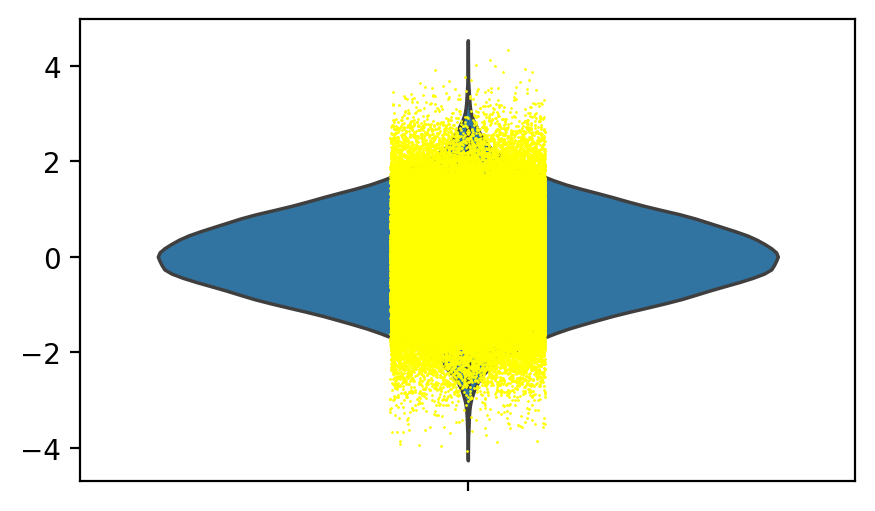

In [ ]:
import seaborn as sns
sns.violinplot(data)
sns.stripplot(data, color='yellow', size =1)
plt.show()

<Axes: xlabel='Species', ylabel='Sepal.Length'>

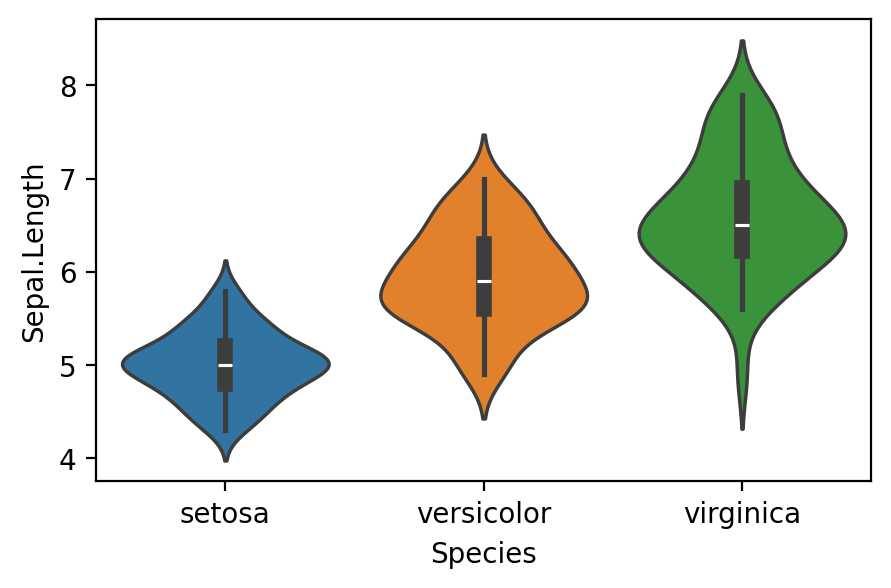

In [ ]:
from pydataset import data
iris = data('iris')
import seaborn as sns
sns.violinplot(data=iris, x='Species', y='Sepal.Length', hue='Species')

<Axes: xlabel='Species', ylabel='Sepal.Length'>

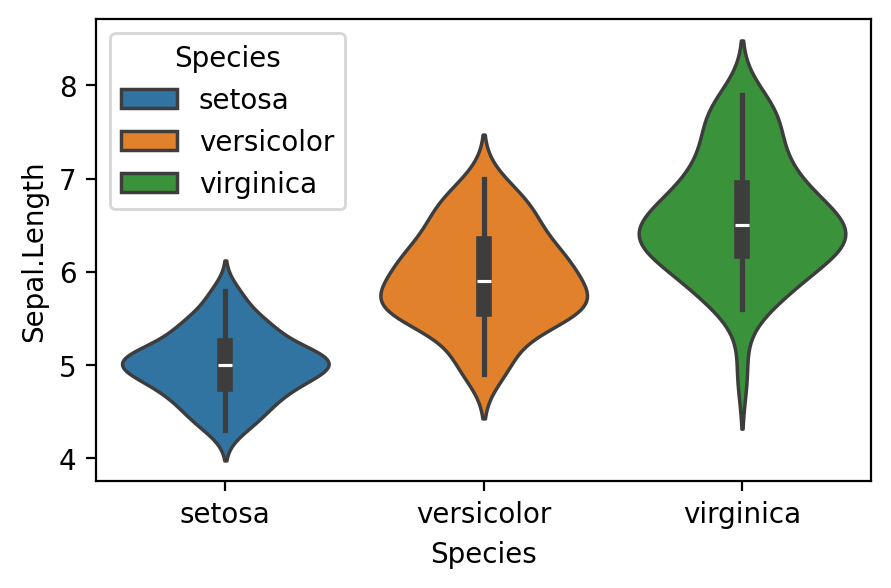

In [ ]:
sns.violinplot(iris, x='Species', y='Sepal.Length', hue='Species', legend='full')

In [ ]:
from pydataset import data
mtc = data('mtcars')
mtc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


In [ ]:
display_side_by_side(mtc.head(), mtc.tail())

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.9,1,1,5,2
Ford Pantera L,15.8,8,351.0,264,4.22,3.170,14.5,0,1,5,4
Ferrari Dino,19.7,6,145.0,175,3.62,2.770,15.5,0,1,5,6
Maserati Bora,15.0,8,301.0,335,3.54,3.570,14.6,0,1,5,8


In [ ]:
mincar = mtc.iloc[:, :4]
display_side_by_side(mincar.head(), mincar.tail())

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93
Hornet 4 Drive,21.4,6,258.0,110
Hornet Sportabout,18.7,8,360.0,175
,mpg,cyl,disp,hp
Lotus Europa,30.4,4,95.1,113
Ford Pantera L,15.8,8,351.0,264
Ferrari Dino,19.7,6,145.0,175
Maserati Bora,15.0,8,301.0,335


In [ ]:
mcar = mtc[mtc.columns[:4].to_list()]
display_side_by_side(mincar.head(), mincar.tail())

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93
Hornet 4 Drive,21.4,6,258.0,110
Hornet Sportabout,18.7,8,360.0,175
,mpg,cyl,disp,hp
Lotus Europa,30.4,4,95.1,113
Ford Pantera L,15.8,8,351.0,264
Ferrari Dino,19.7,6,145.0,175
Maserati Bora,15.0,8,301.0,335


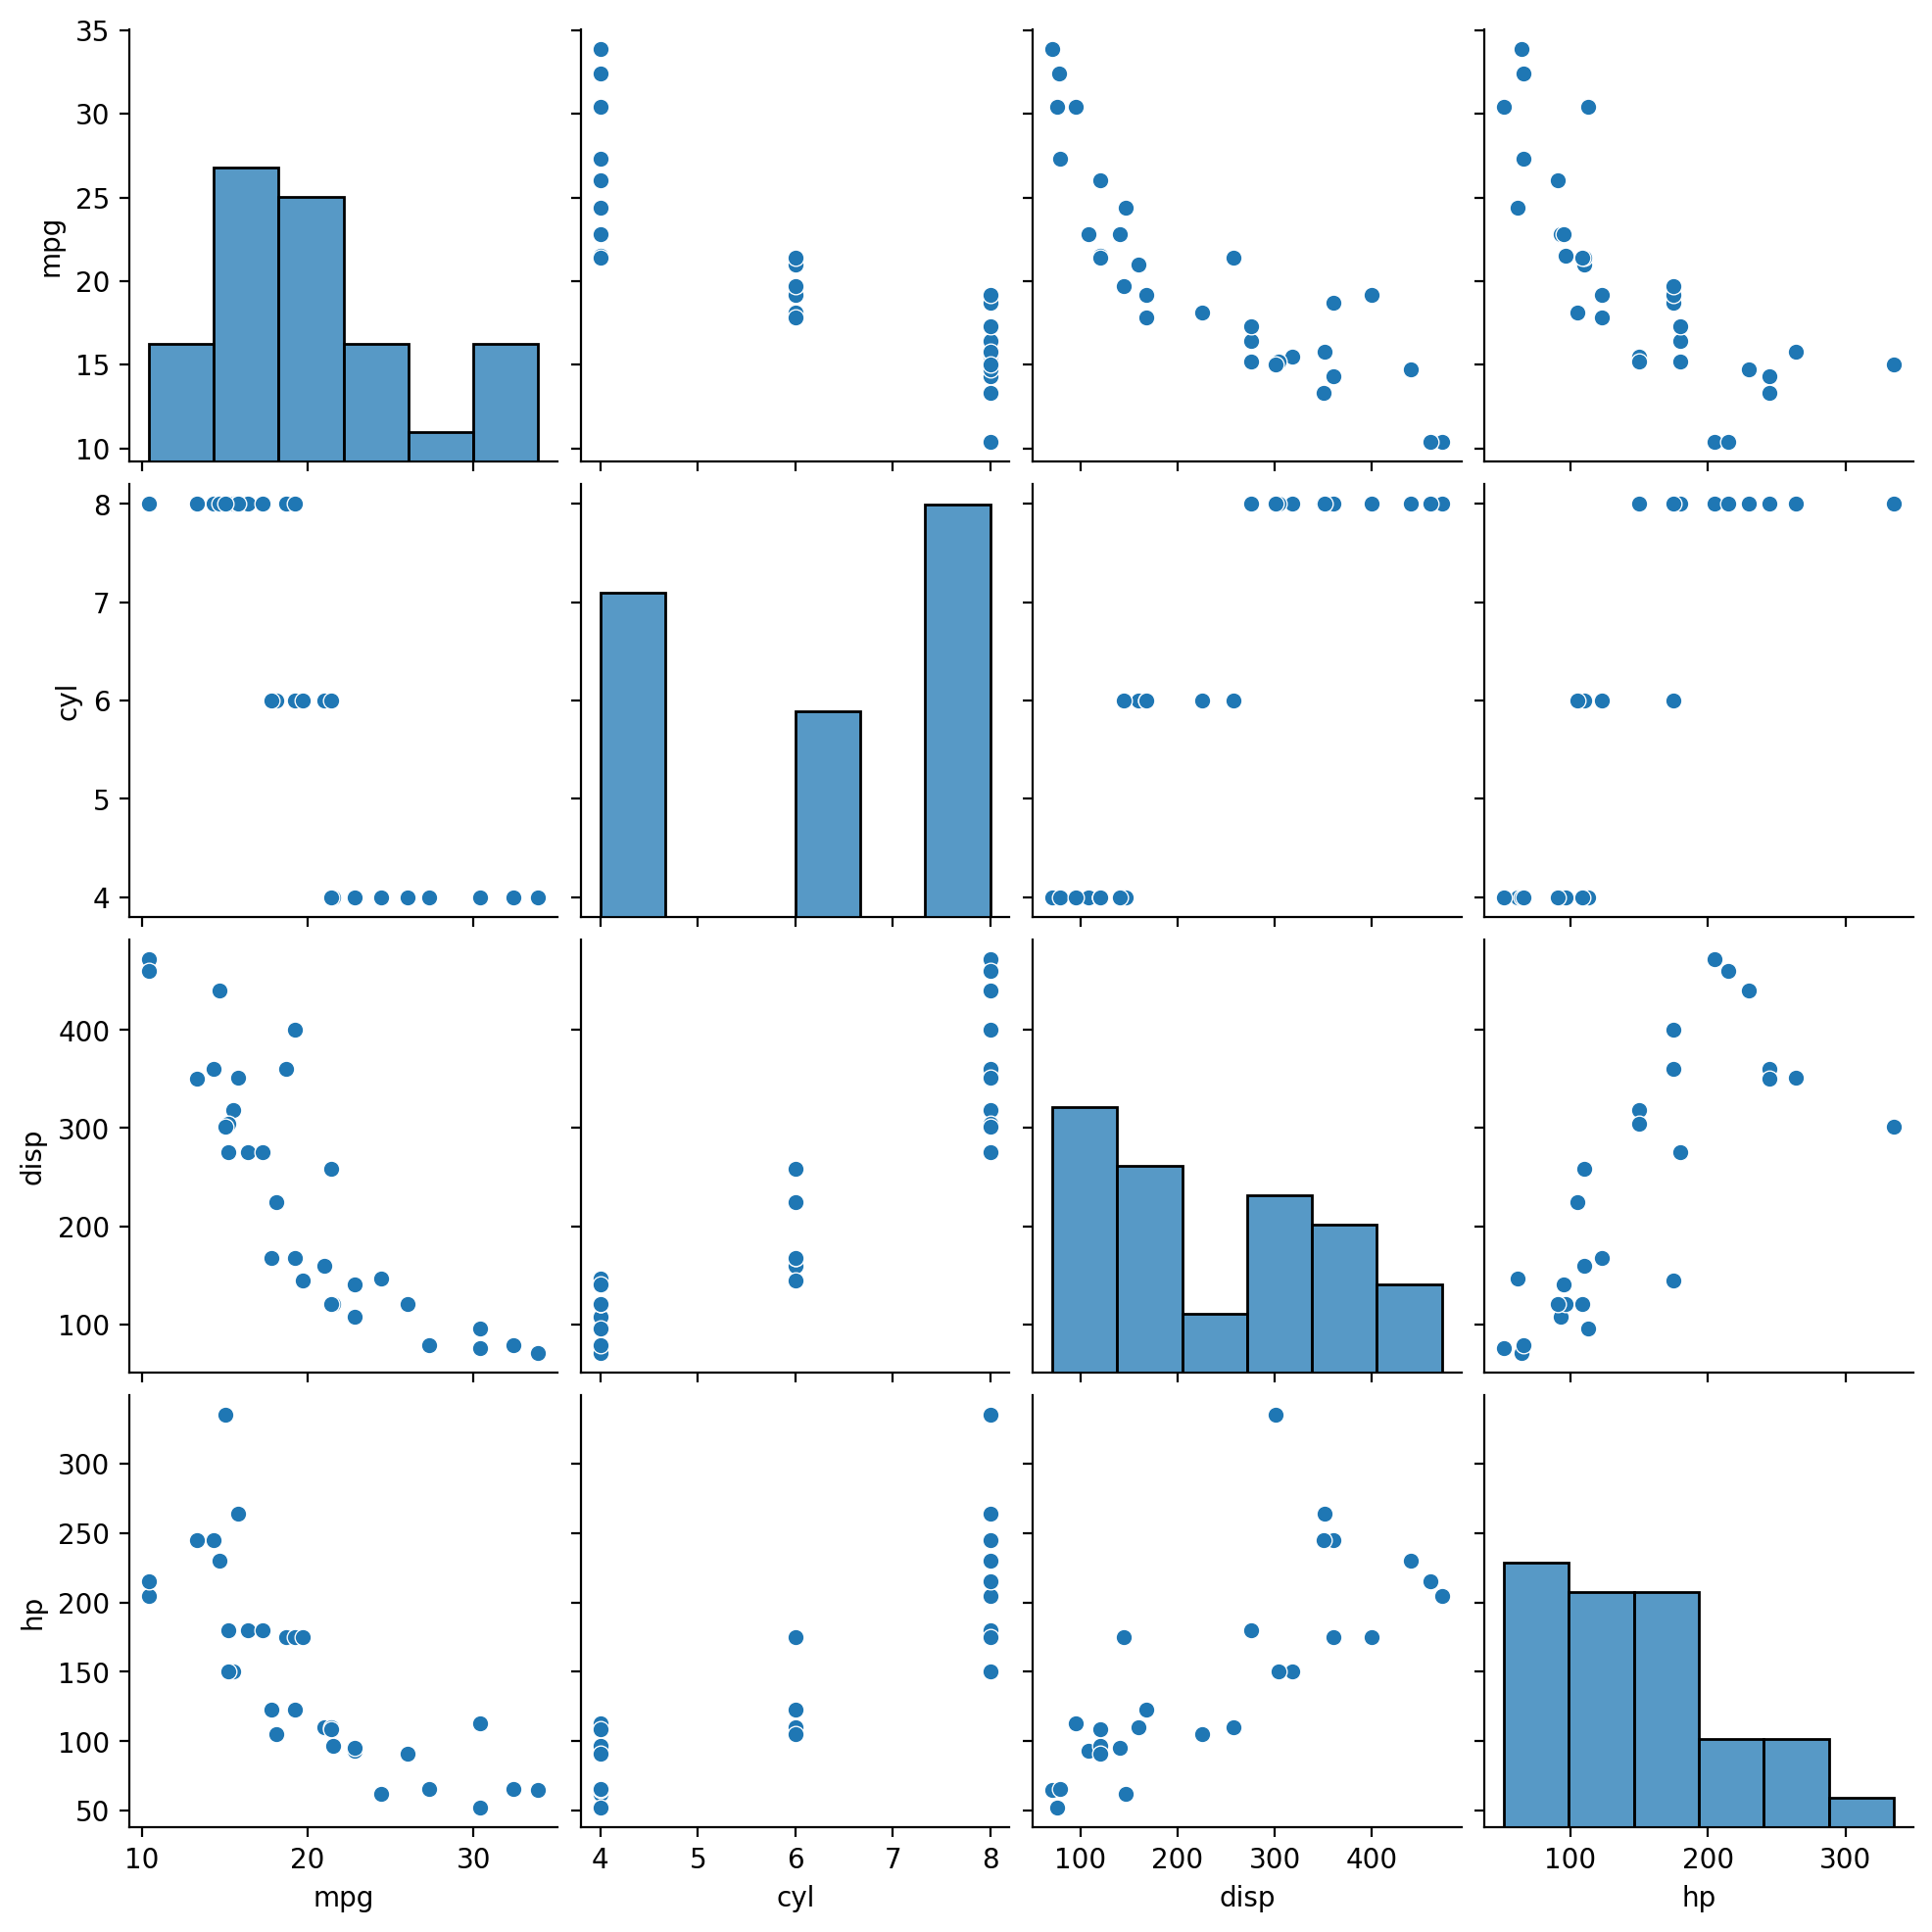

In [ ]:
import seaborn as sns
sns.pairplot(mcar)

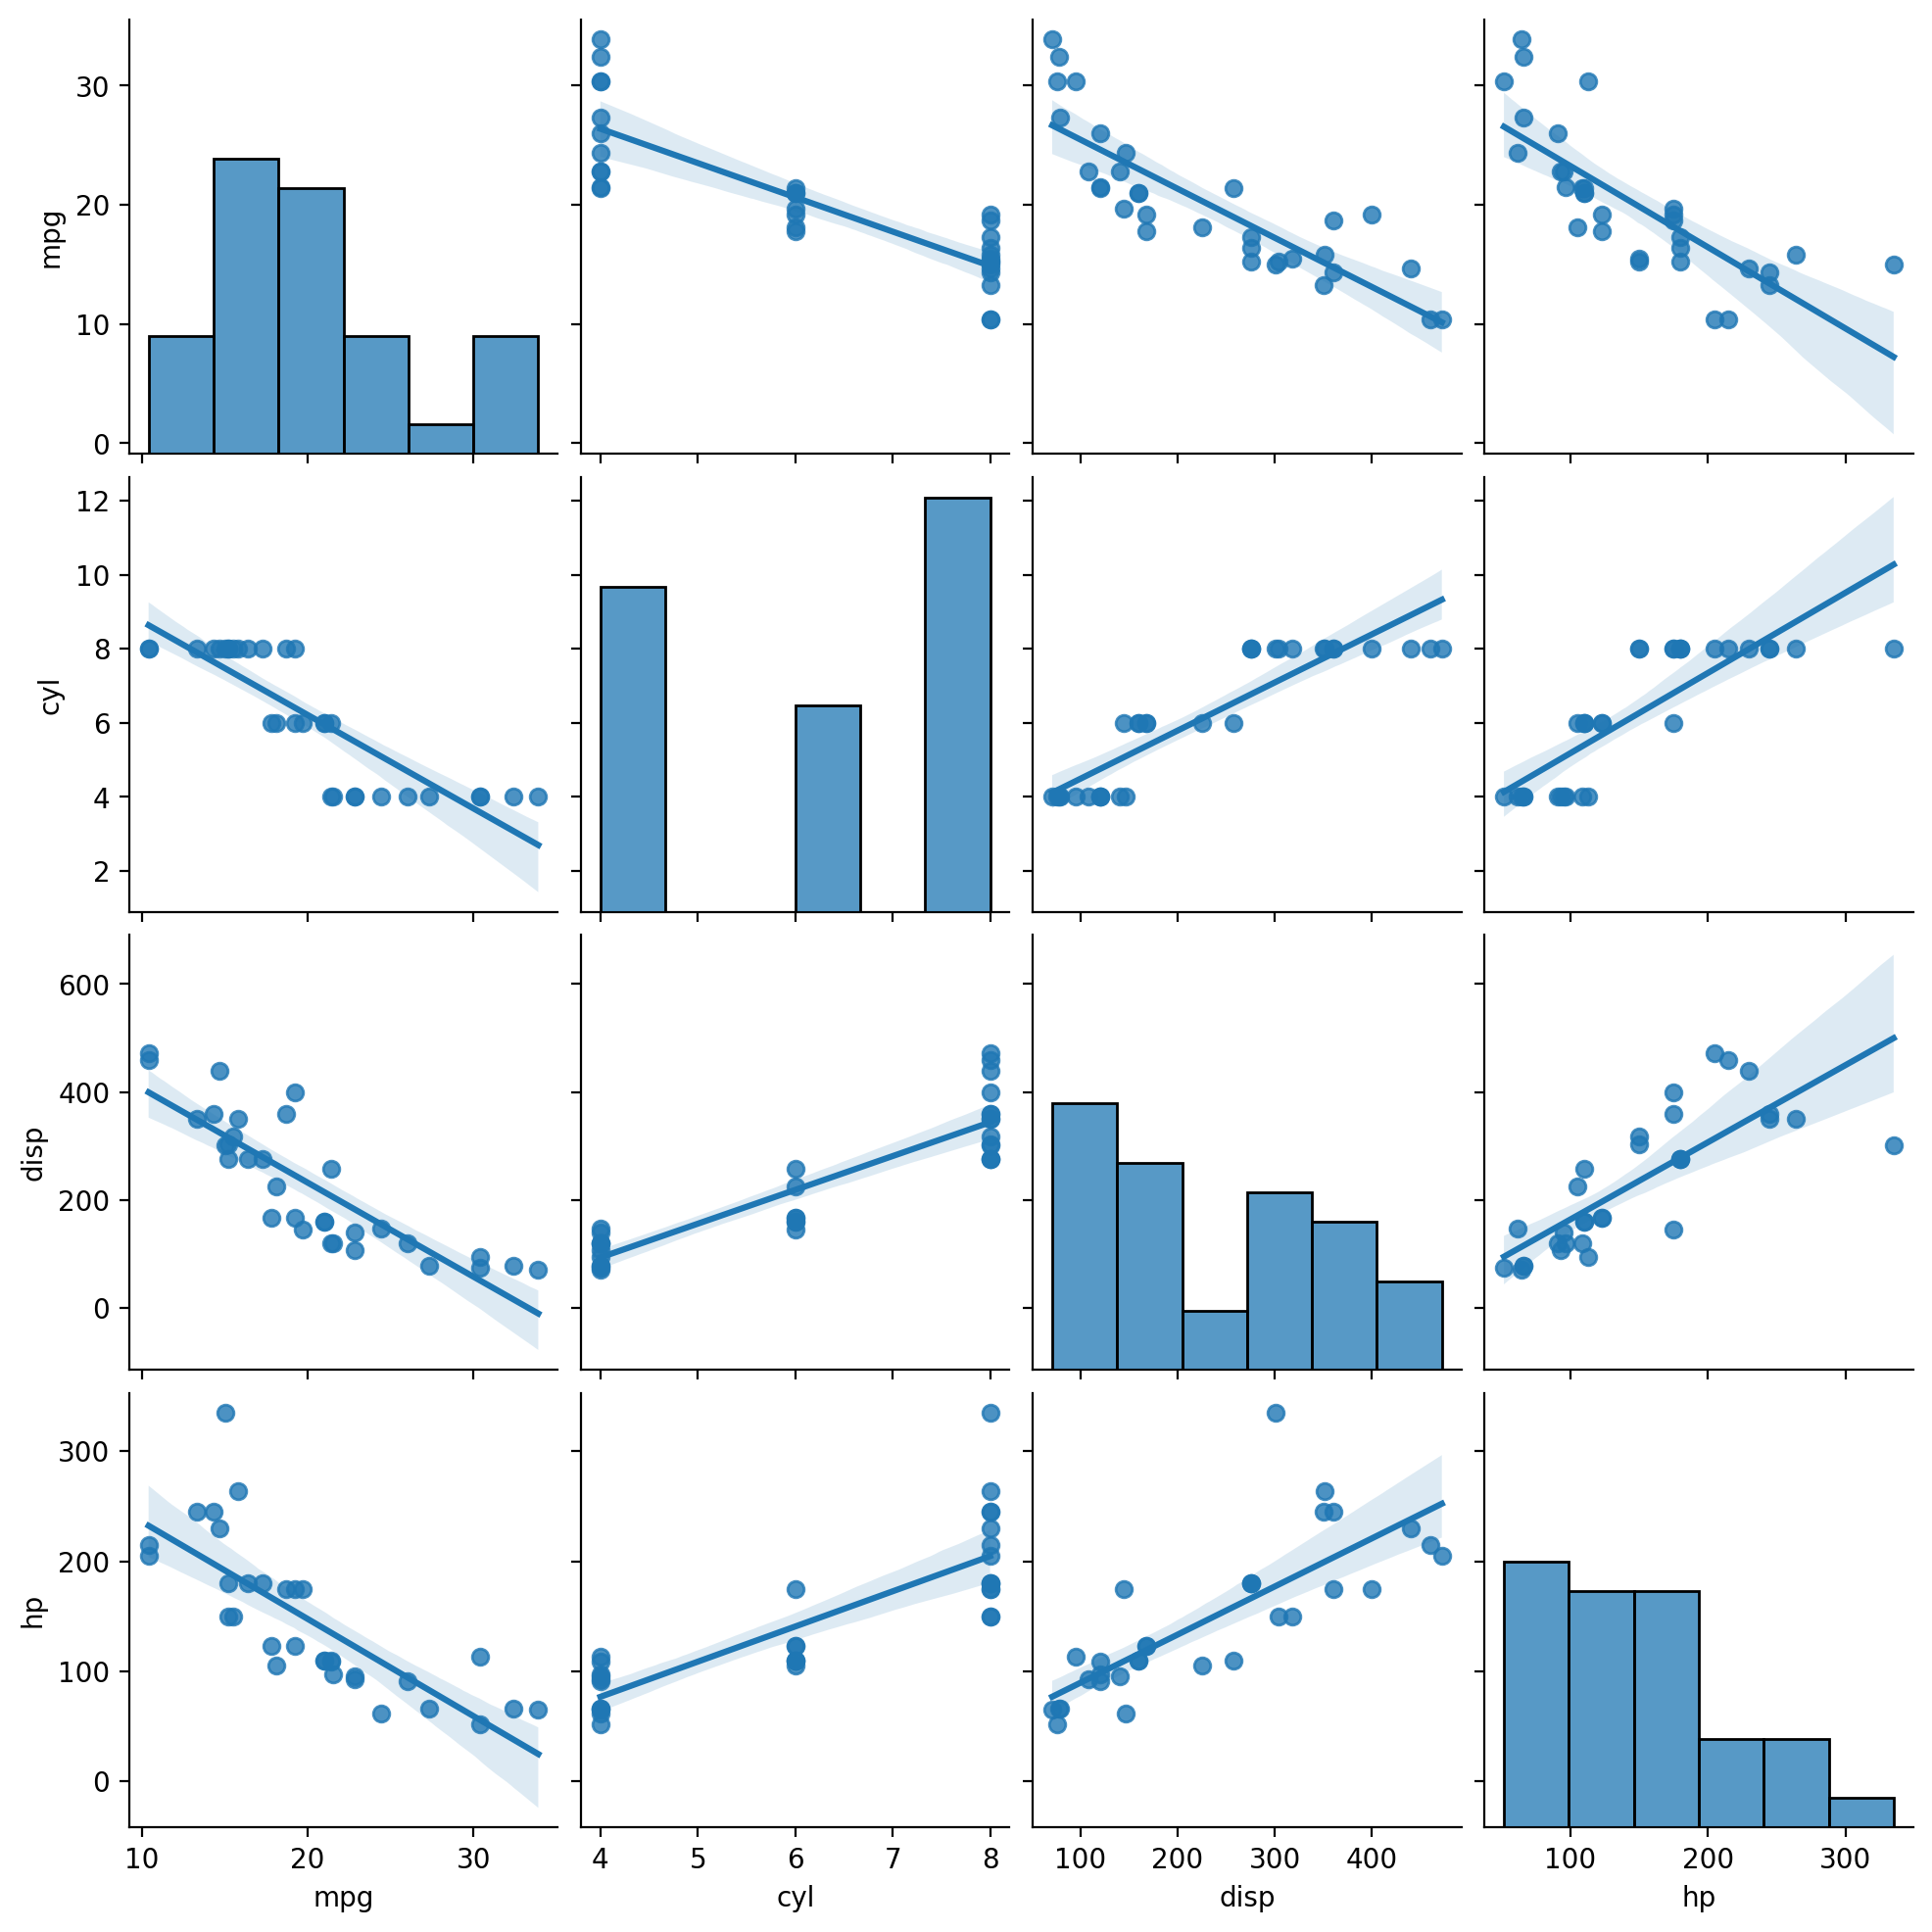

In [ ]:
sns.pairplot(mcar, kind='reg')

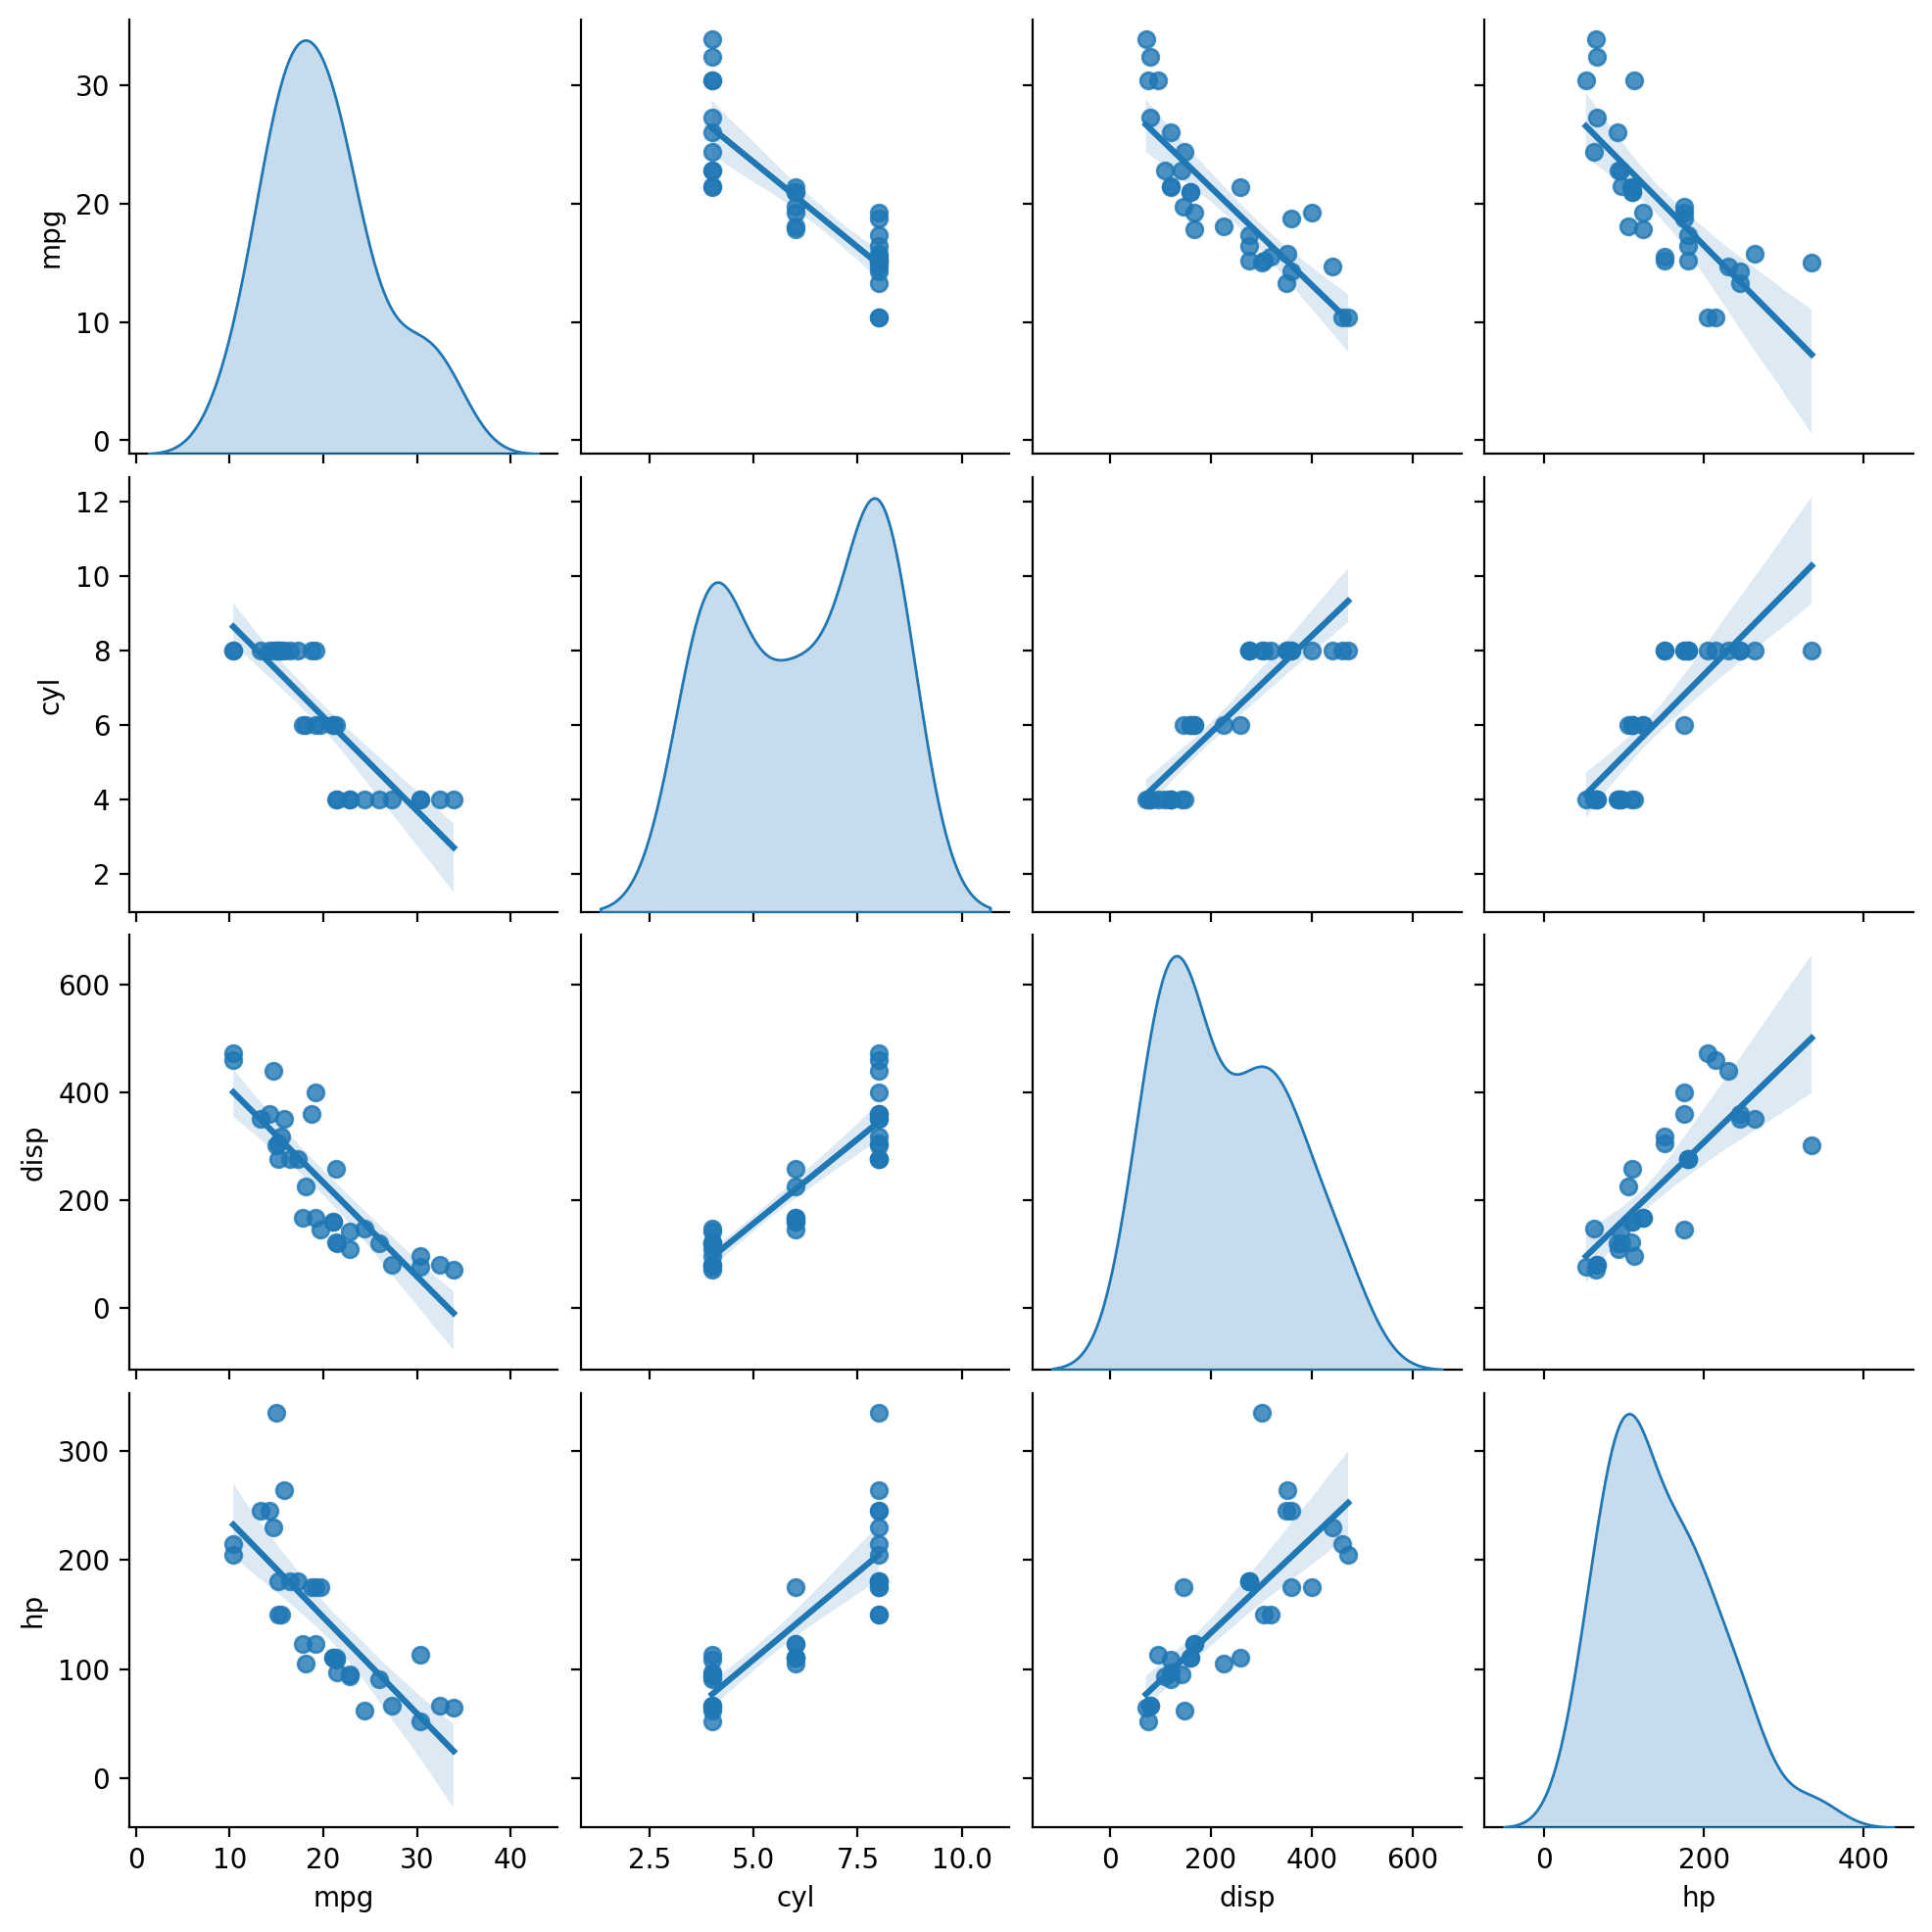

In [ ]:
sns.pairplot(mcar, kind='reg',diag_kind="kde")

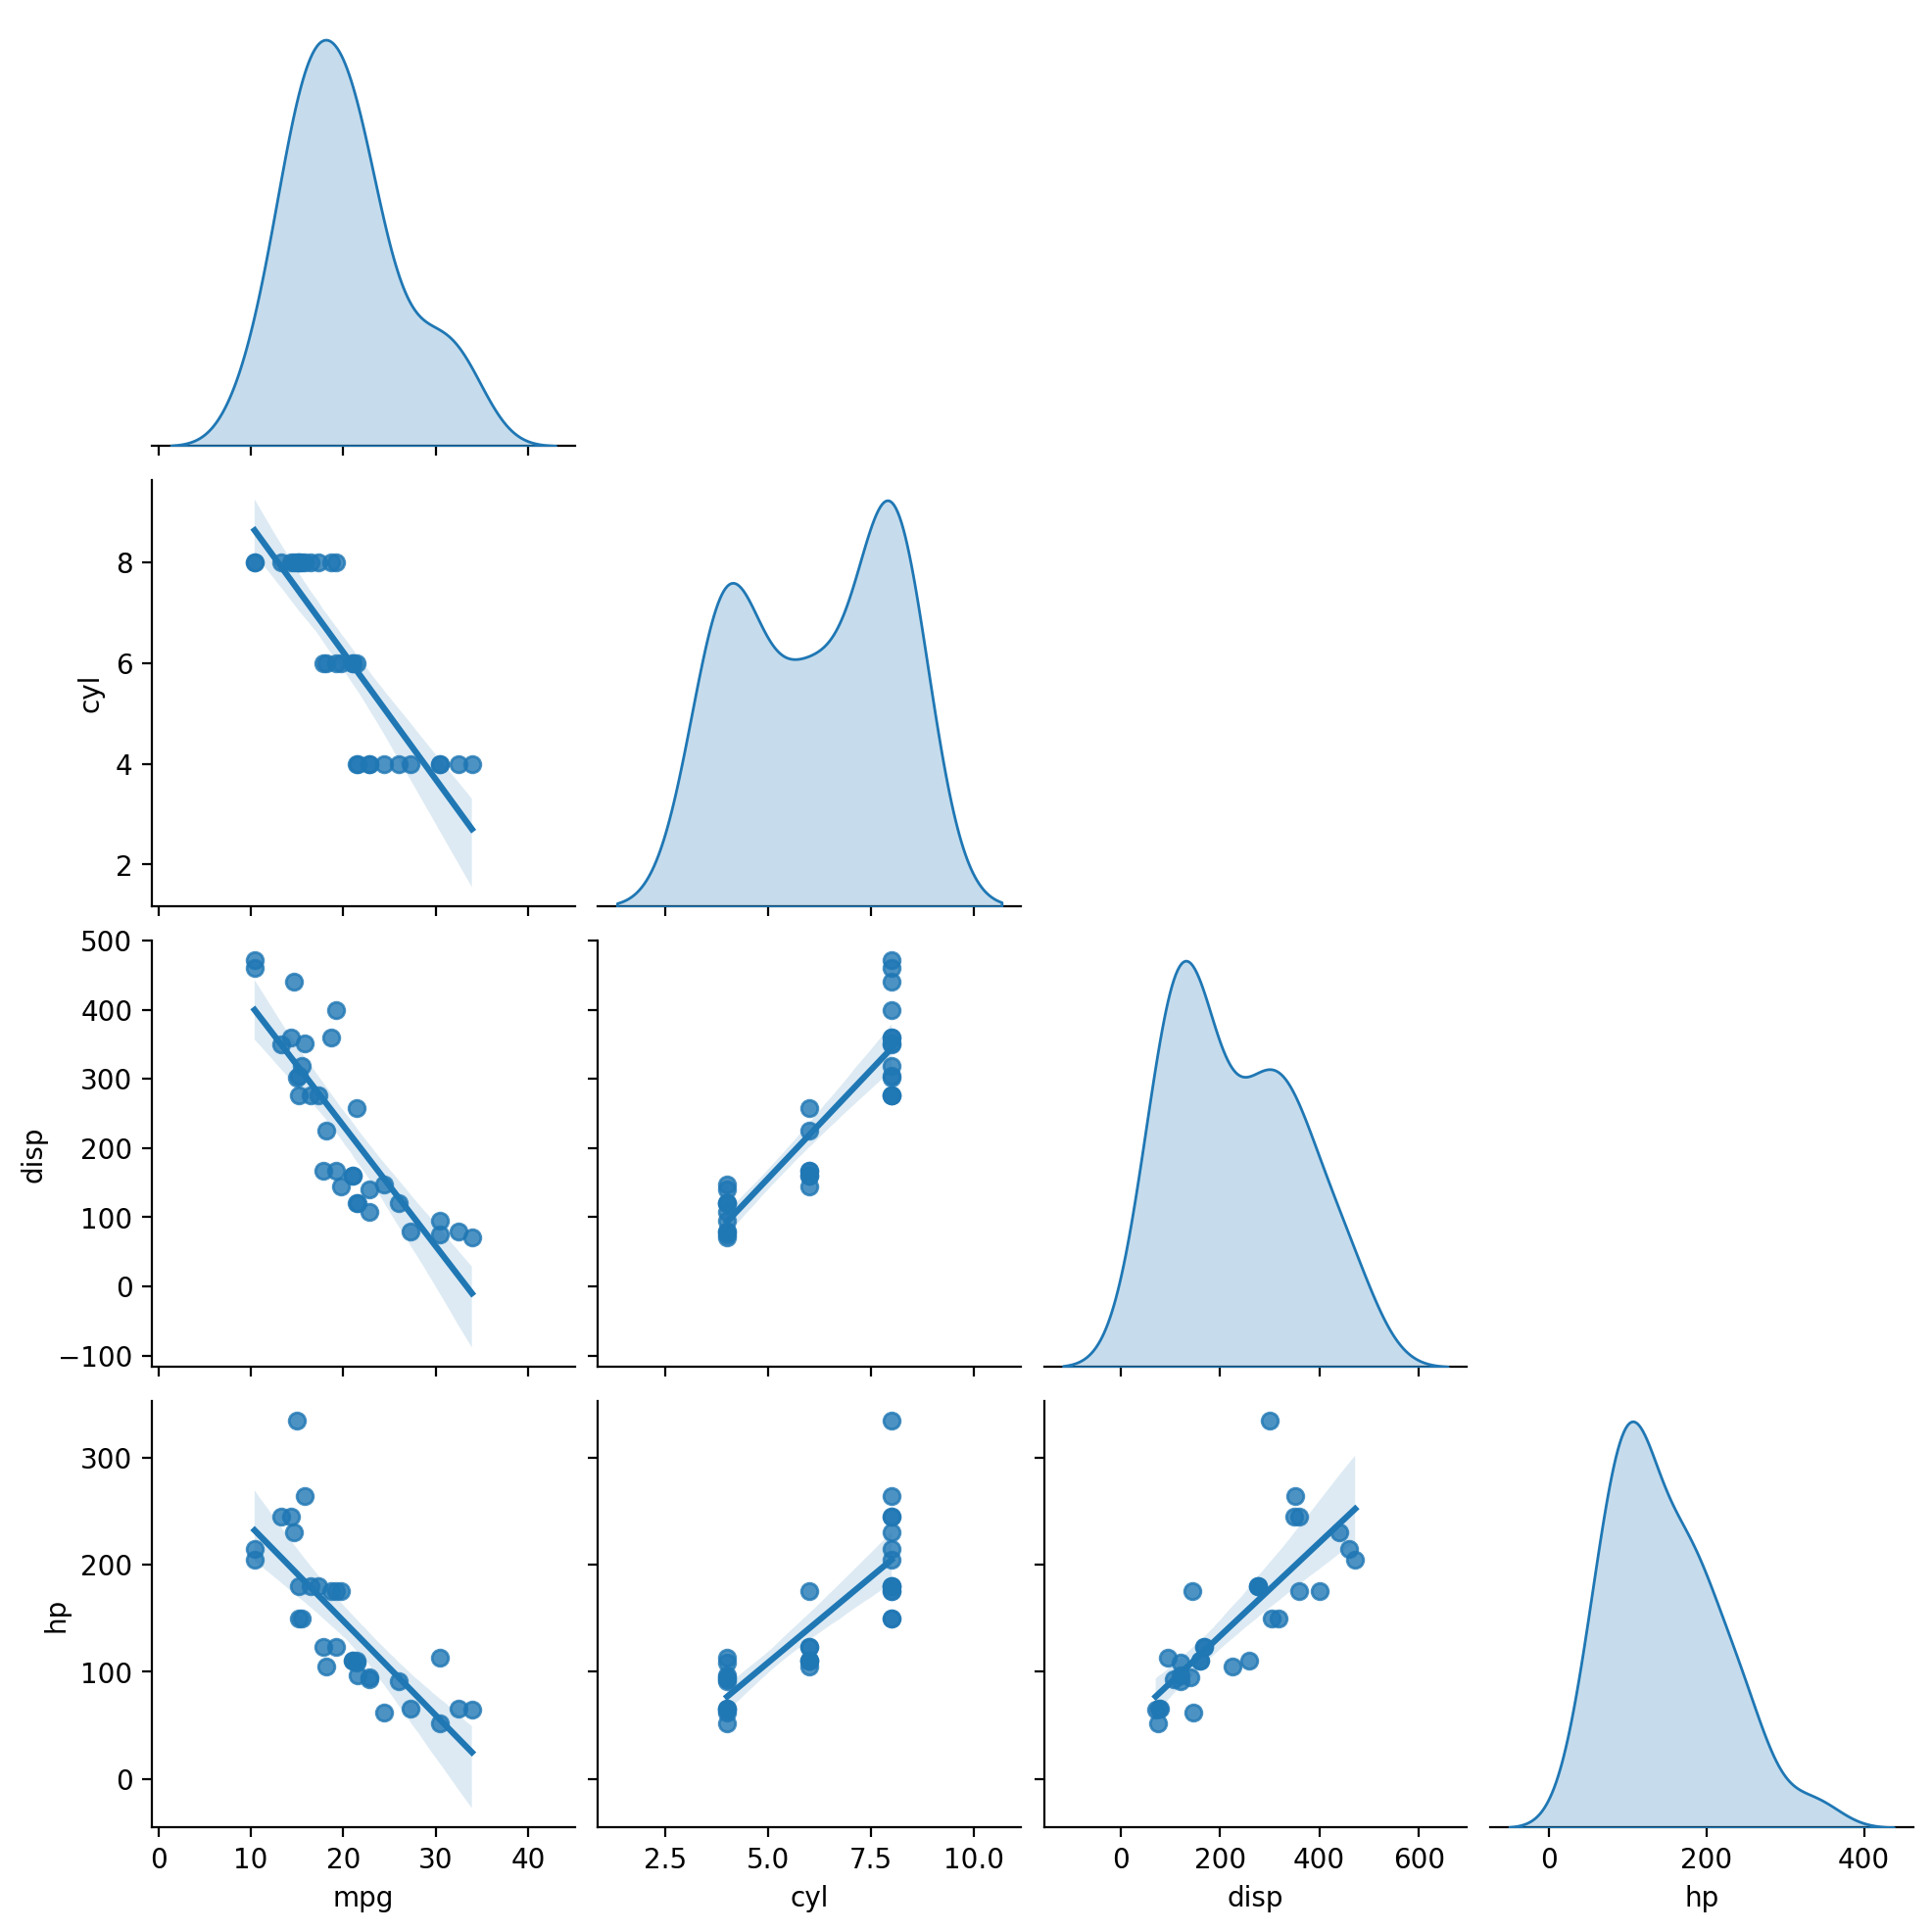

In [ ]:
sns.pairplot(mcar, kind='reg',diag_kind="kde", corner=True)

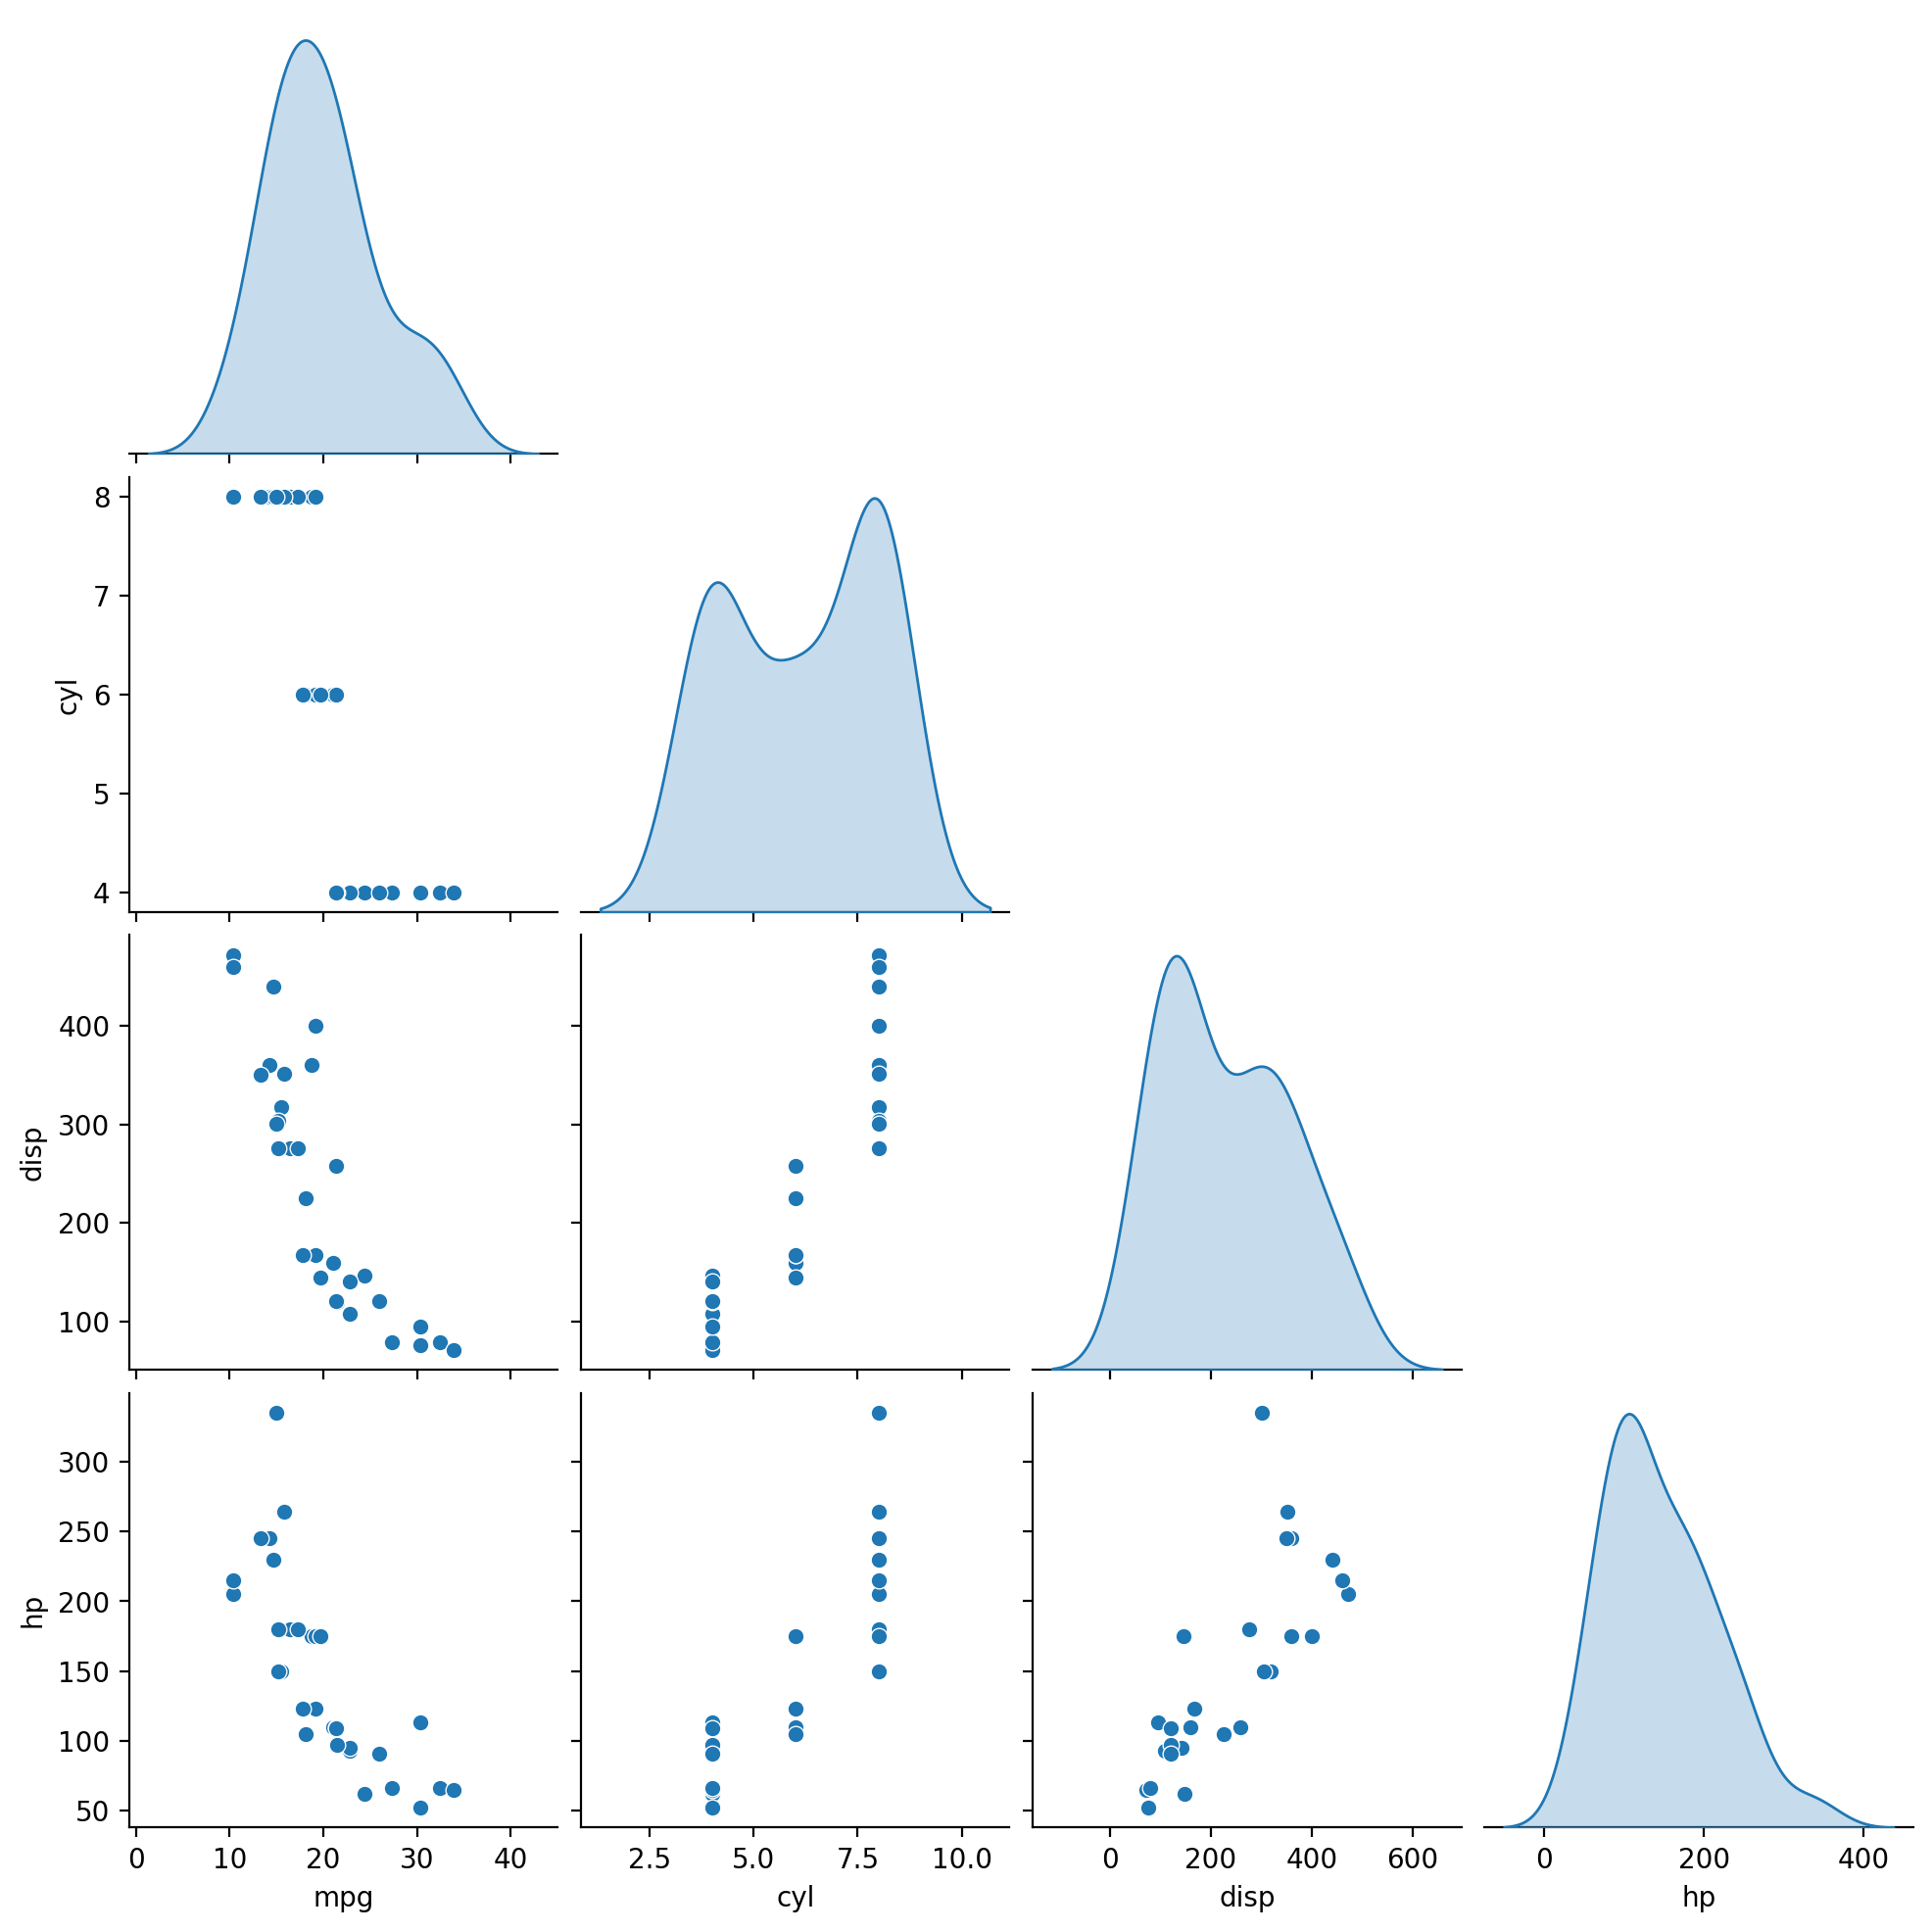

In [ ]:
sns.pairplot(mcar ,diag_kind="kde", corner=True)

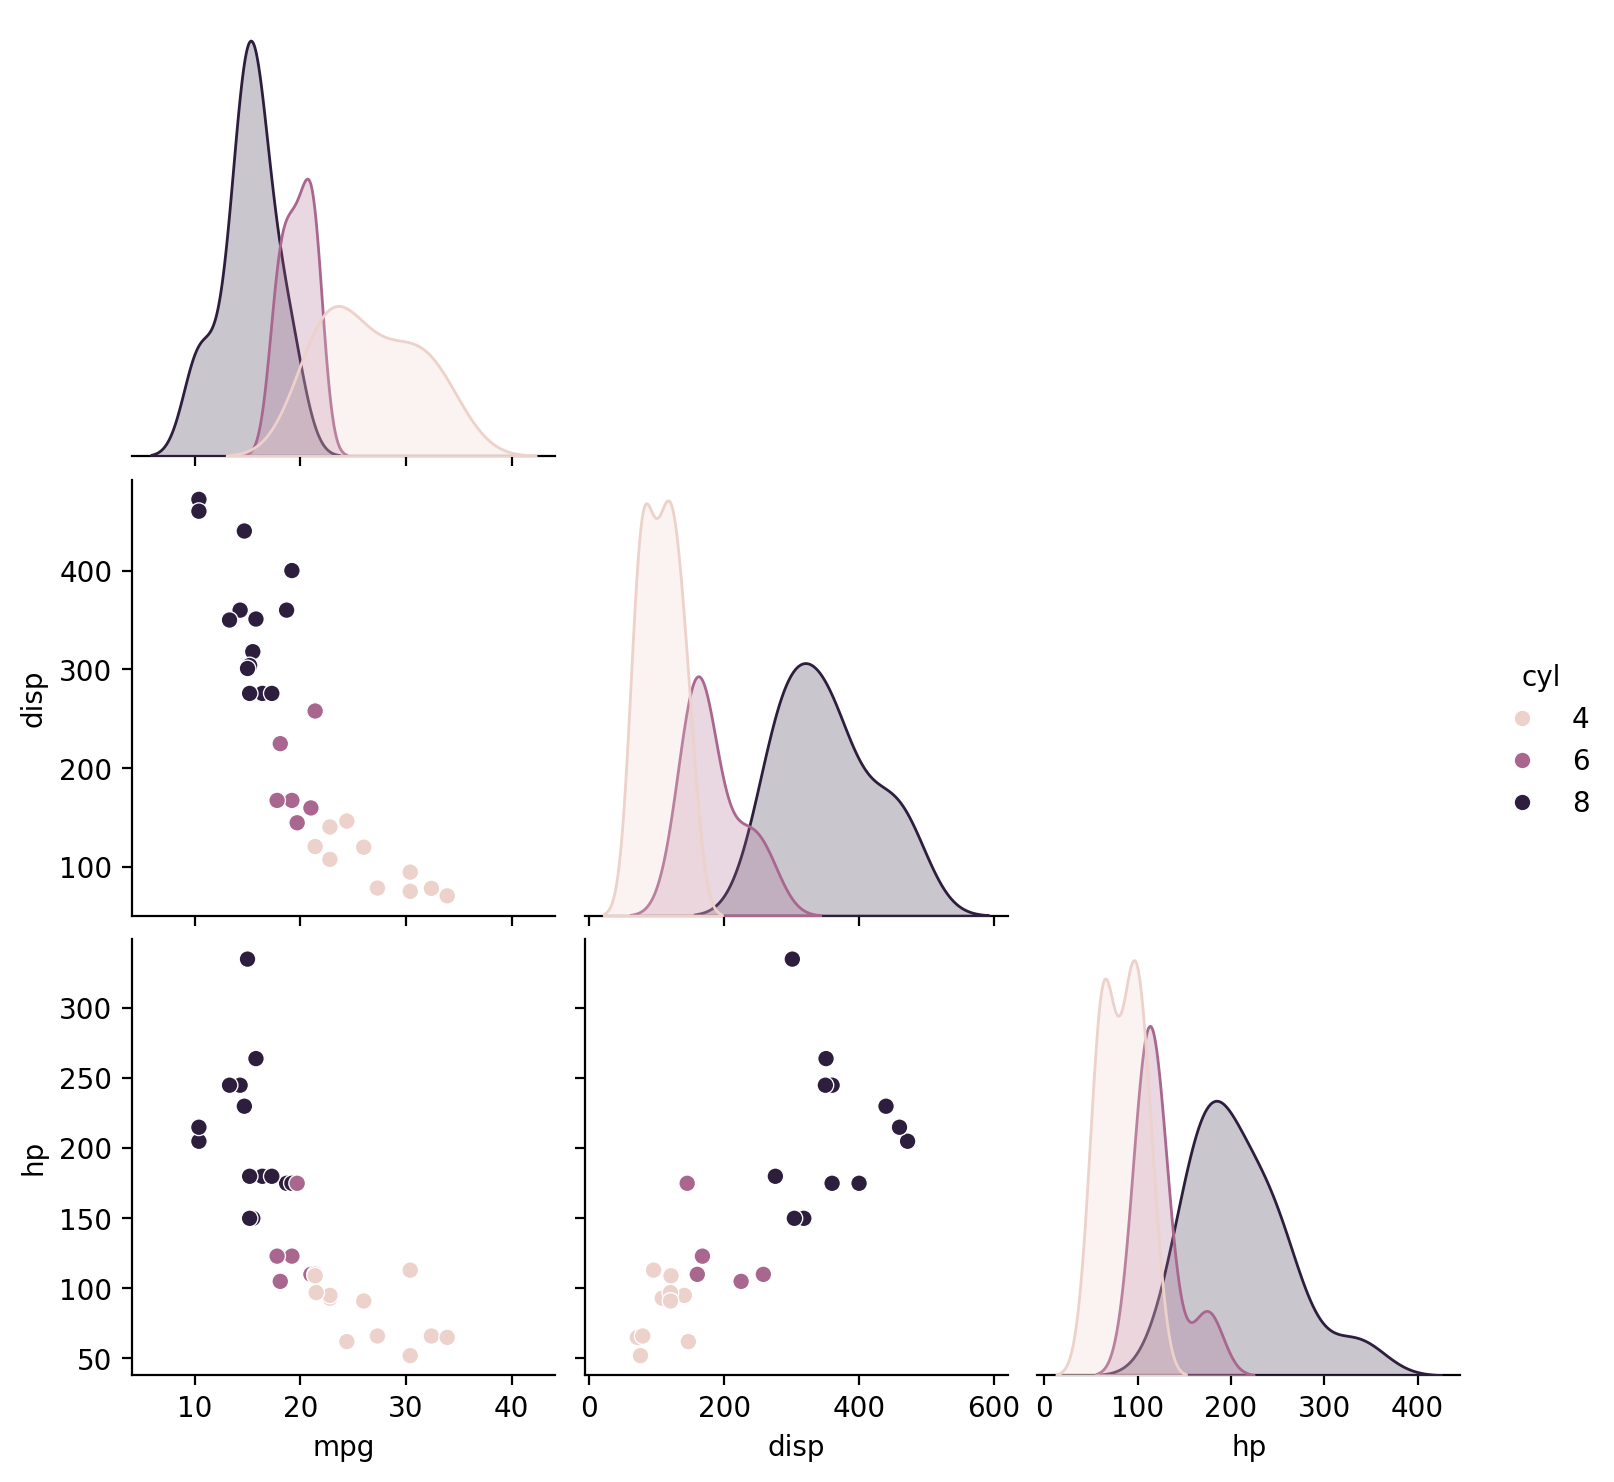

In [ ]:
sns.pairplot(mcar, diag_kind="kde", hue= 'cyl', corner=True)

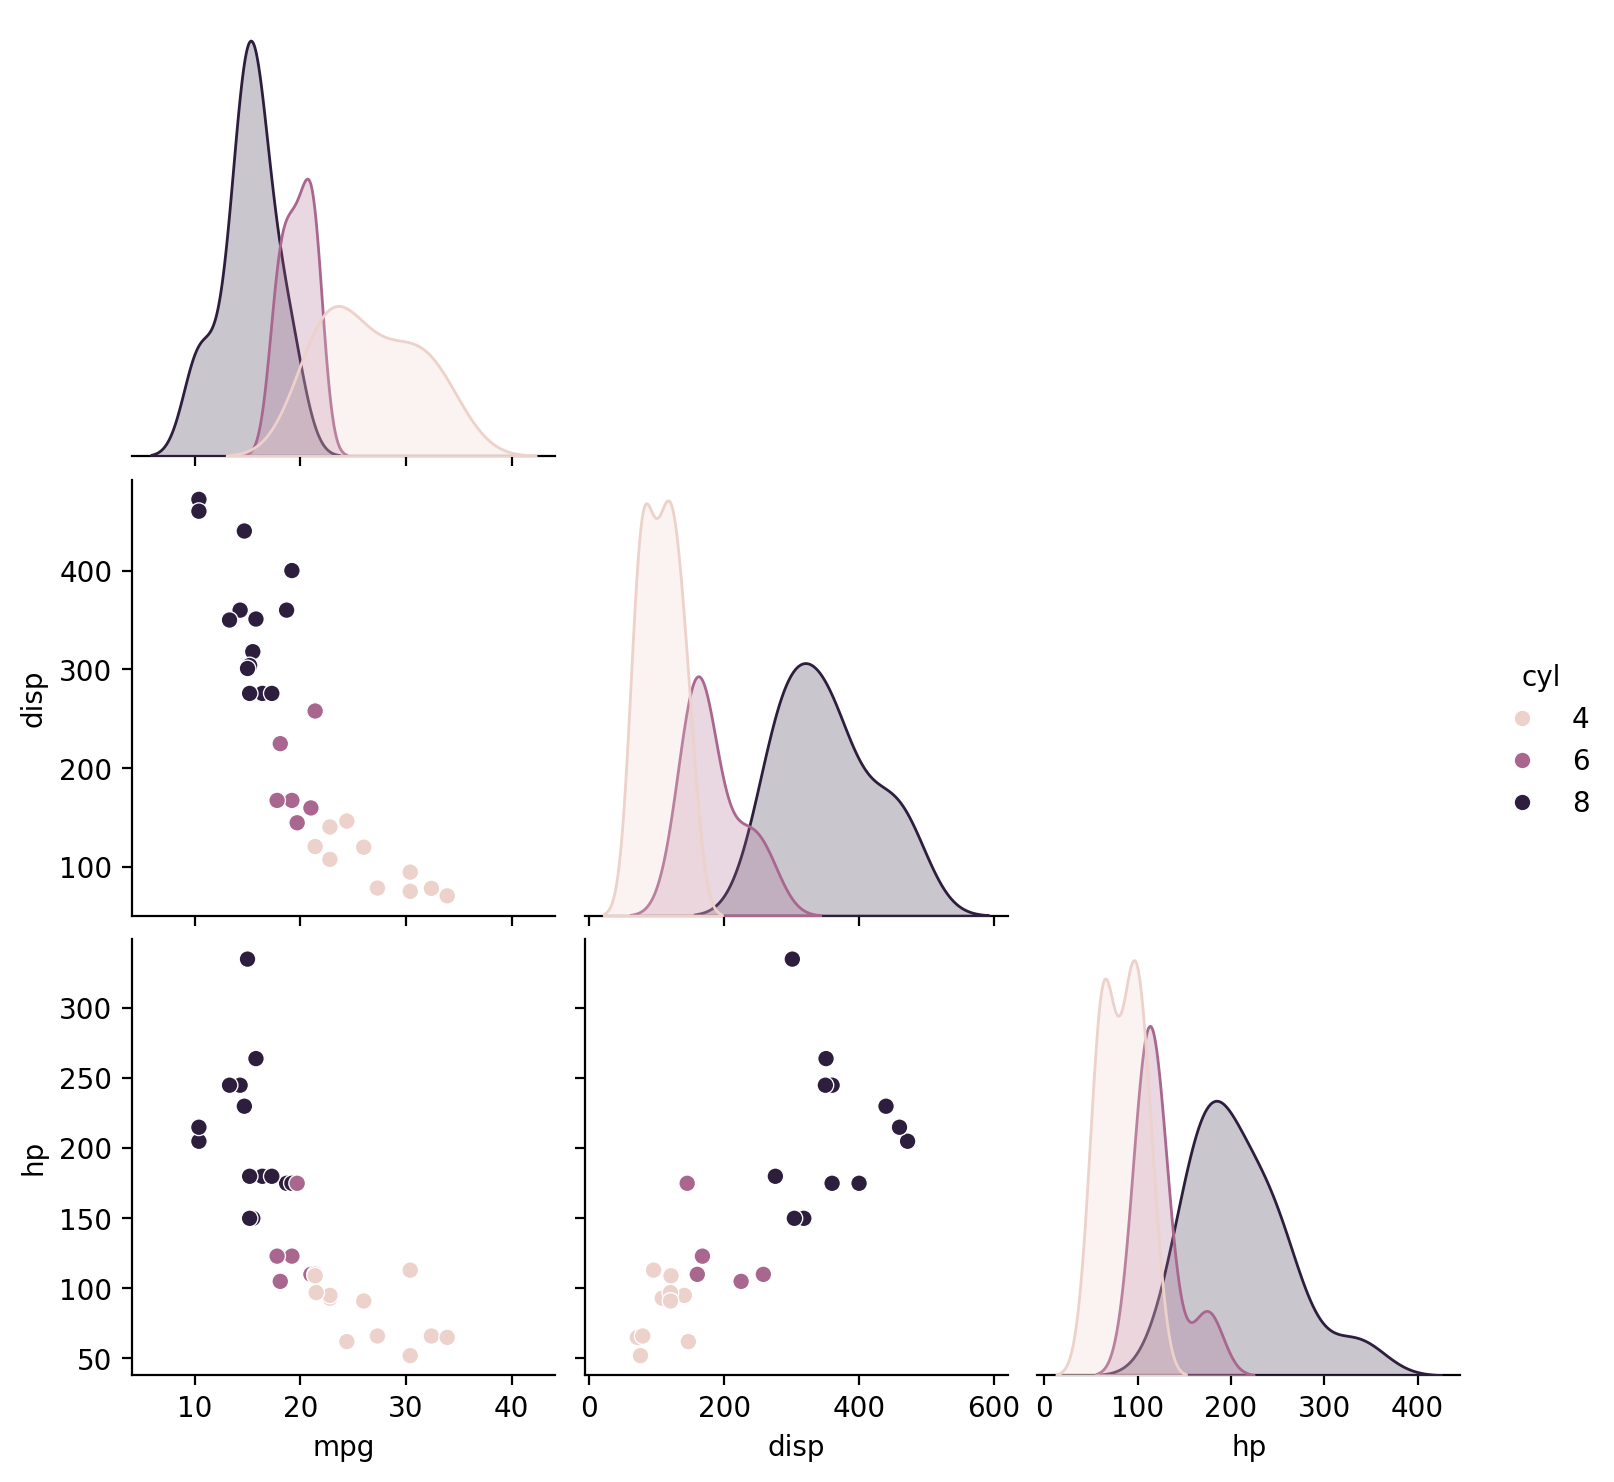

In [ ]:
sns.pairplot(mcar, hue= 'cyl', corner=True)

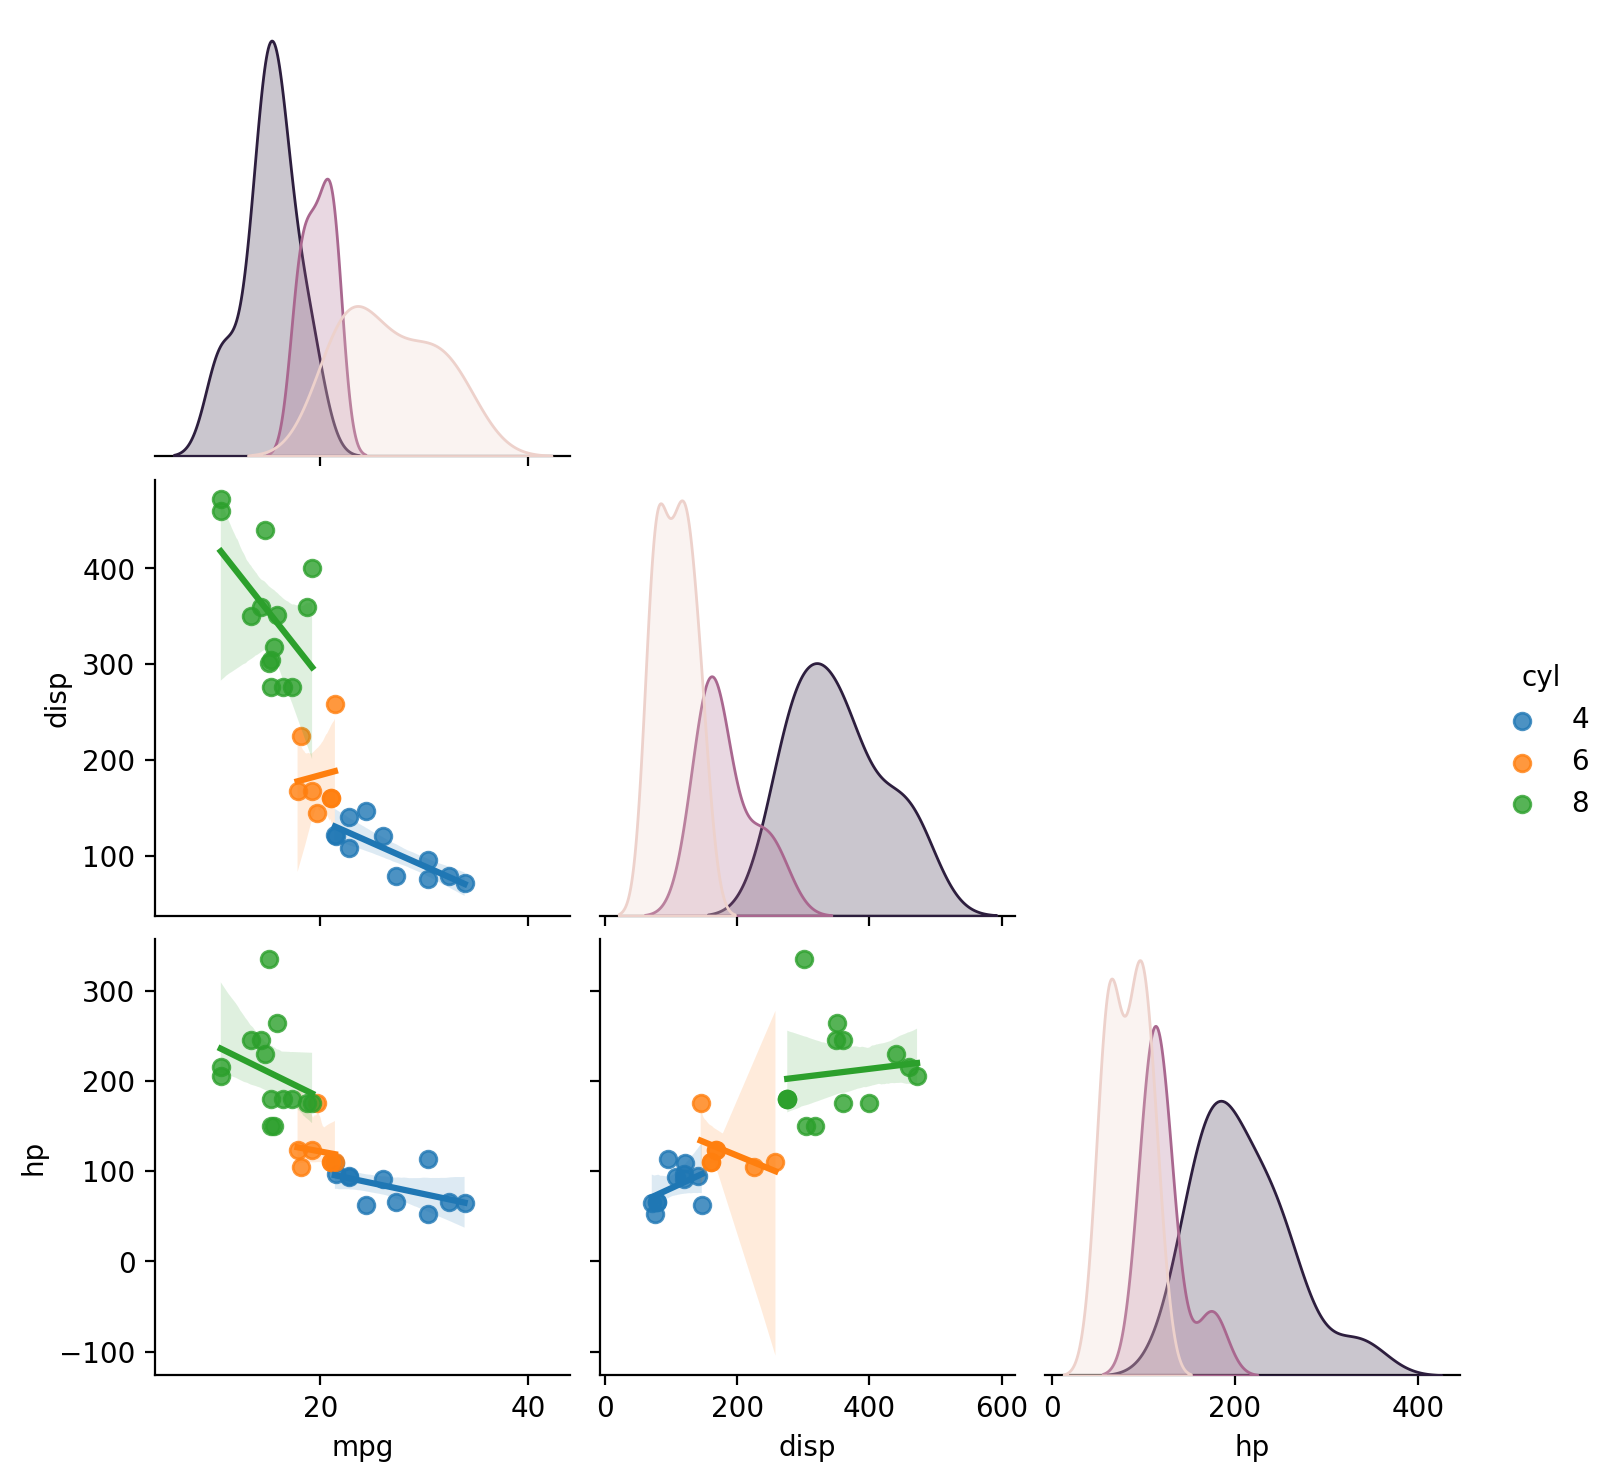

In [ ]:
sns.pairplot(mcar, hue= 'cyl', diag_kind="kde", corner=True, kind='reg')
plt.show()

In [ ]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris = sns.load_dataset('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
import pandas as pd
pd.set_option('display.precision', 3)
corr_iris = iris[iris.columns[:-1].to_list()].corr()
corr_iris

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


In [ ]:
pd.set_option('display.precision', 2)

In [ ]:
corr = iris[iris.columns[:-1].to_list()]
corr

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [ ]:
corr = iris[iris.columns[:-1].to_list()].corr()
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.12,0.87,0.82
sepal_width,-0.12,1.00,-0.43,-0.37
petal_length,0.87,-0.43,1.00,0.96
petal_width,0.82,-0.37,0.96,1.00


<Axes: >

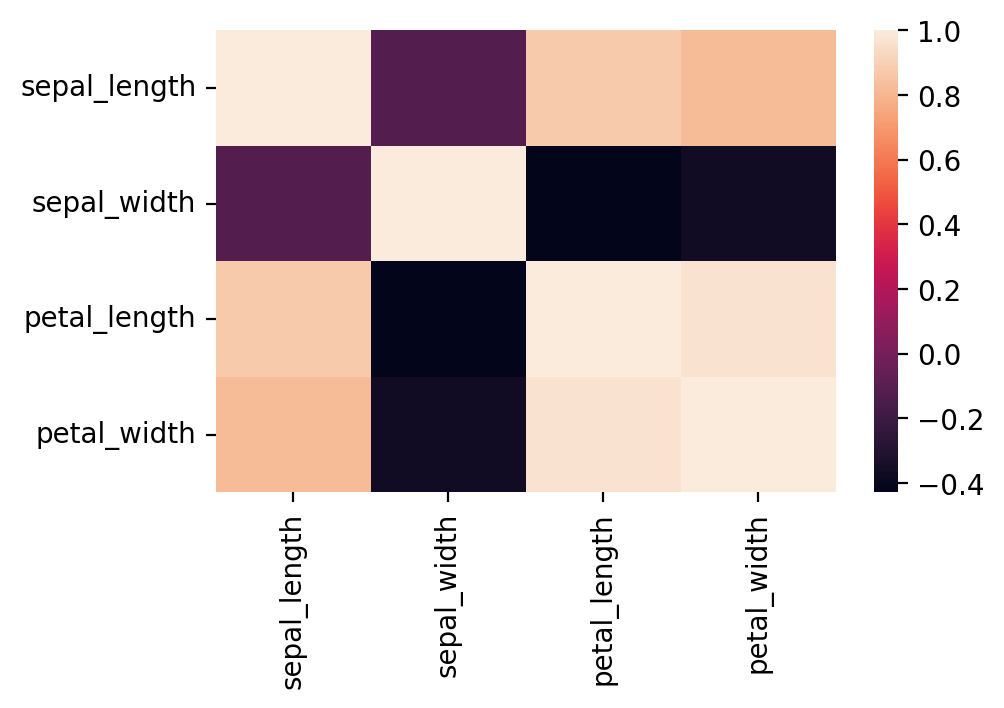

In [ ]:
sns.heatmap(corr)

<Axes: >

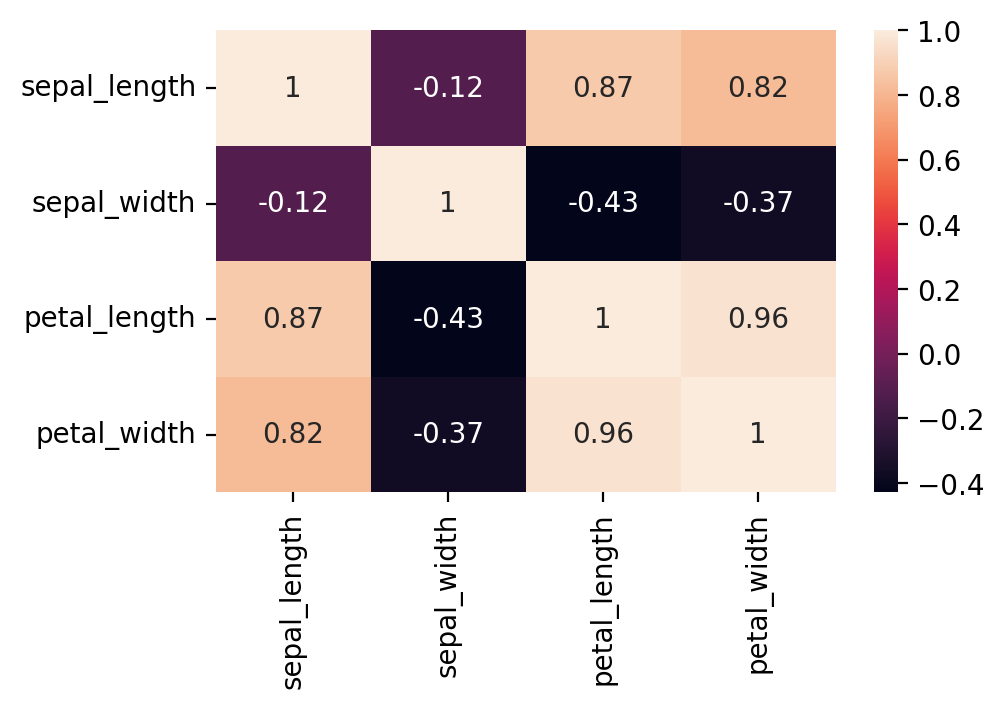

In [ ]:
sns.heatmap(corr, annot=True)

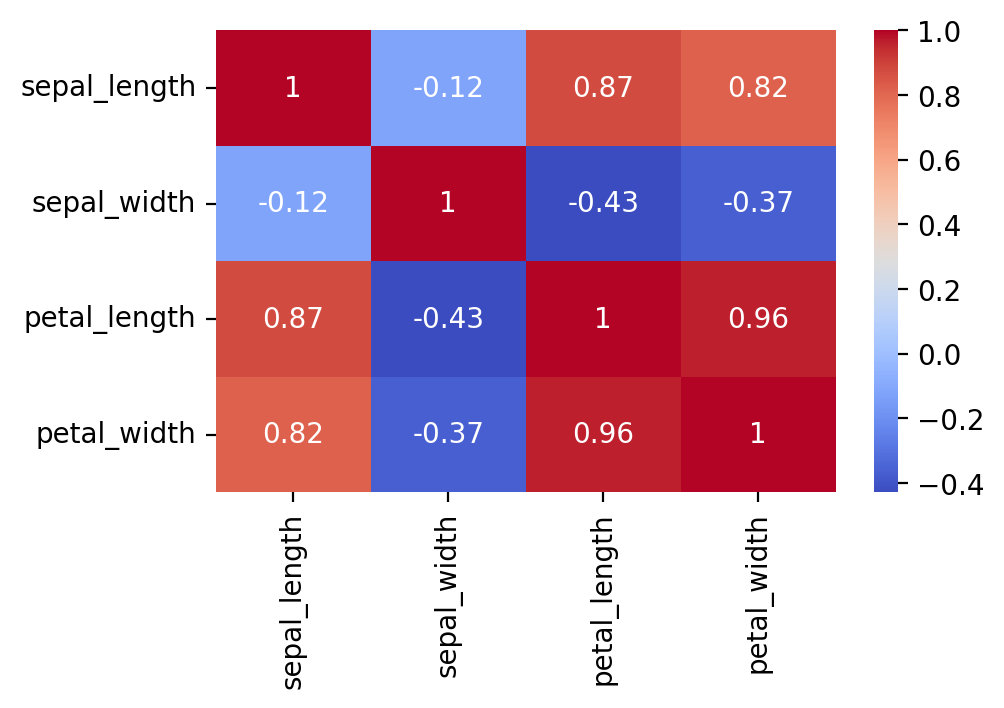

In [ ]:
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.show()

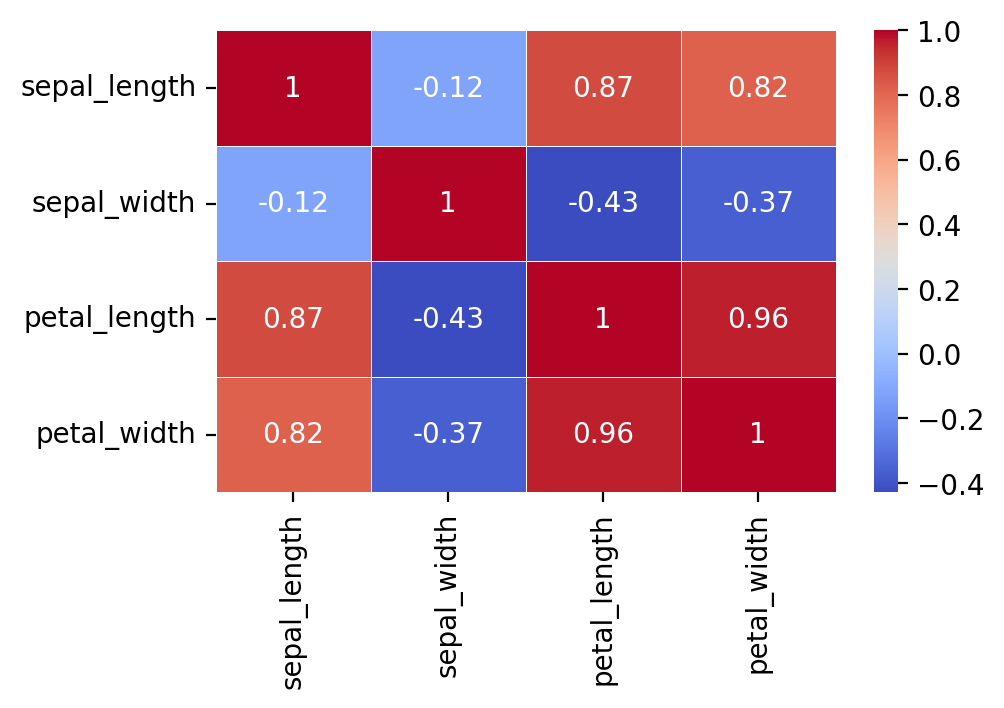

In [ ]:
sns.heatmap(corr, cmap='coolwarm', annot=True, lw=.2)
plt.show()

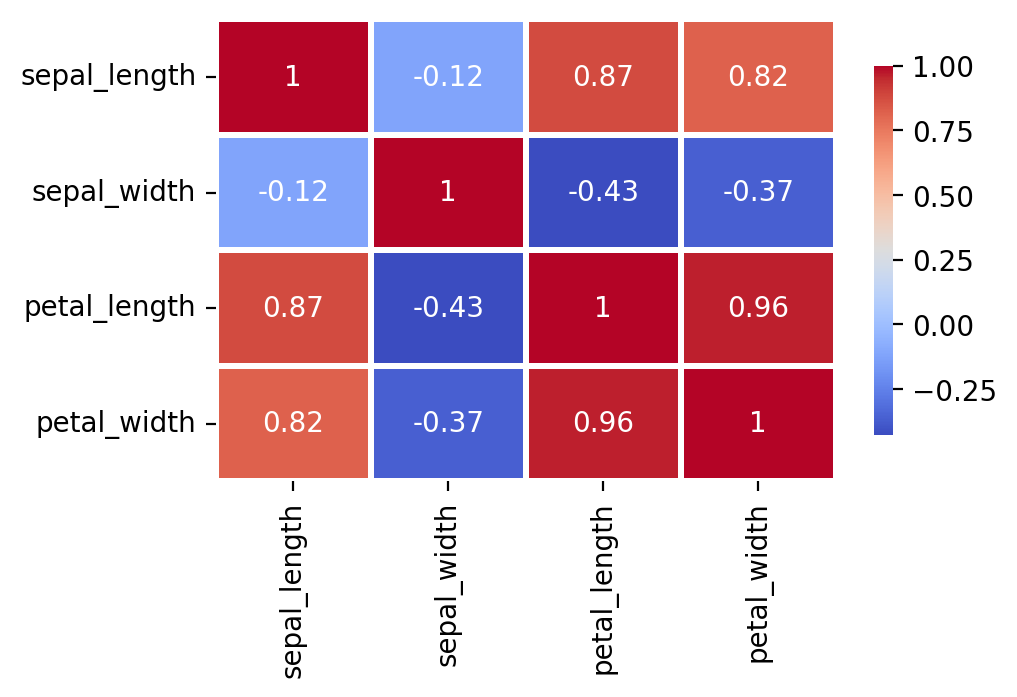

In [ ]:
sns.heatmap(corr, cmap='coolwarm', annot=True, lw=2,cbar_kws={'shrink':.8})
plt.show()

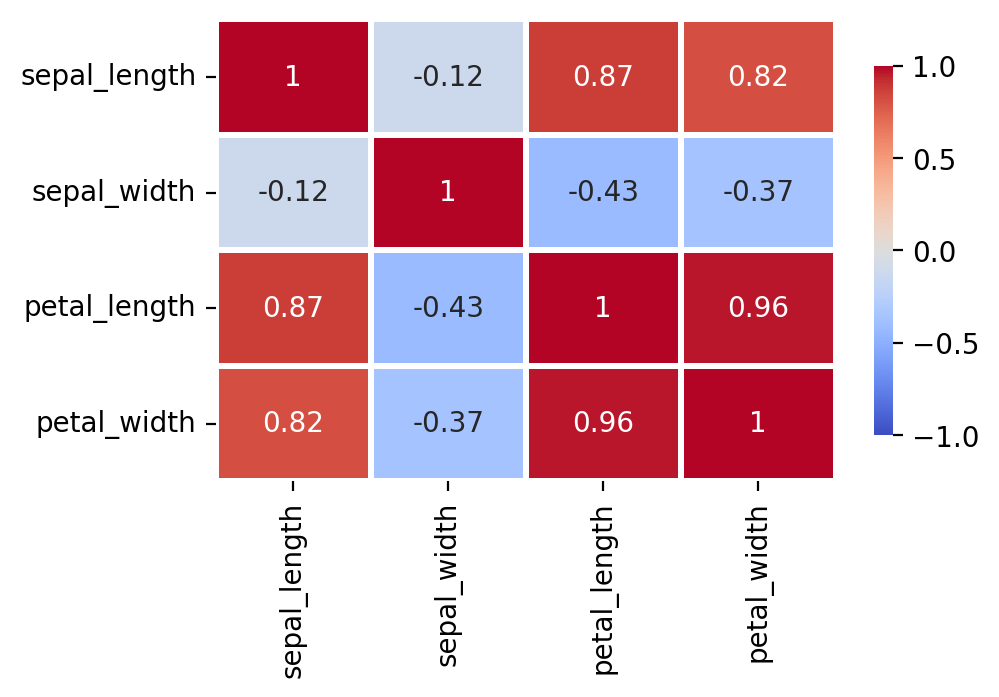

In [ ]:
sns.heatmap(corr, cmap='coolwarm', annot=True, lw=2,cbar_kws={'shrink':.8},
            vmin=-1, vmax=1)
plt.show()

In [ ]:
mask = np.zeros_like(corr)
mask

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
np.triu_indices_from(mask)

(array([0, 0, 0, 0, 1, 1, 1, 2, 2, 3]), array([0, 1, 2, 3, 1, 2, 3, 2, 3, 3]))

In [ ]:
mask[0, 0]

np.float64(0.0)

In [ ]:
mask[[0, 1], [0, 1]]

array([0., 0.])

In [ ]:
mask[[0, 0, 0, 0, 1, 1, 1, 2, 2, 3], [0, 1, 2, 3, 1, 2, 3, 2, 3, 3]]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
mask[np.triu_indices_from(mask)] = True
mask

array([[1., 1., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.]])

In [ ]:
mask[1:, :-1]

array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]])

In [ ]:
new_mask = mask[1:, :-1]
new_mask

array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]])

In [ ]:
corr.iloc[1:, :-1]

,sepal_length,sepal_width,petal_length
sepal_width,-0.12,1.00,-0.43
petal_length,0.87,-0.43,1.00
petal_width,0.82,-0.37,0.96


In [ ]:
display_side_by_side(corr, corr.iloc[1:, :-1])

sepal_length 
 sepal_width 
 petal_length 
 petal_width 
 
 
 
 
 sepal_length 
 1.00 
 -0.12 
 0.87 
 0.82 
 
 
 sepal_width 
 -0.12 
 1.00 
 -0.43 
 -0.37 
 
 
 petal_length 
 0.87 
 -0.43 
 1.00 
 0.96 
 
 
 petal_width 
 0.82 
 -0.37 
 0.96 
 1.00 
 
 
      
 
 
 
 sepal_length 
 sepal_width 
 petal_length 
 
 
 
 
 sepal_width 
 -0.12 
 1.00 
 -0.43 
 
 
 petal_length 
 0.87 
 -0.43 
 1.00 
 
 
 petal_width 
 0.82 
 -0.37 
 0.96

In [ ]:
display_side_by_side(corr, corr.iloc[1:, :-1])

sepal_length 
 sepal_width 
 petal_length 
 petal_width 
 
 
 
 
 sepal_length 
 1.00 
 -0.12 
 0.87 
 0.82 
 
 
 sepal_width 
 -0.12 
 1.00 
 -0.43 
 -0.37 
 
 
 petal_length 
 0.87 
 -0.43 
 1.00 
 0.96 
 
 
 petal_width 
 0.82 
 -0.37 
 0.96 
 1.00 
 
 
      
 
 
 
 sepal_length 
 sepal_width 
 petal_length 
 
 
 
 
 sepal_width 
 -0.12 
 1.00 
 -0.43 
 
 
 petal_length 
 0.87 
 -0.43 
 1.00 
 
 
 petal_width 
 0.82 
 -0.37 
 0.96

<Axes: >

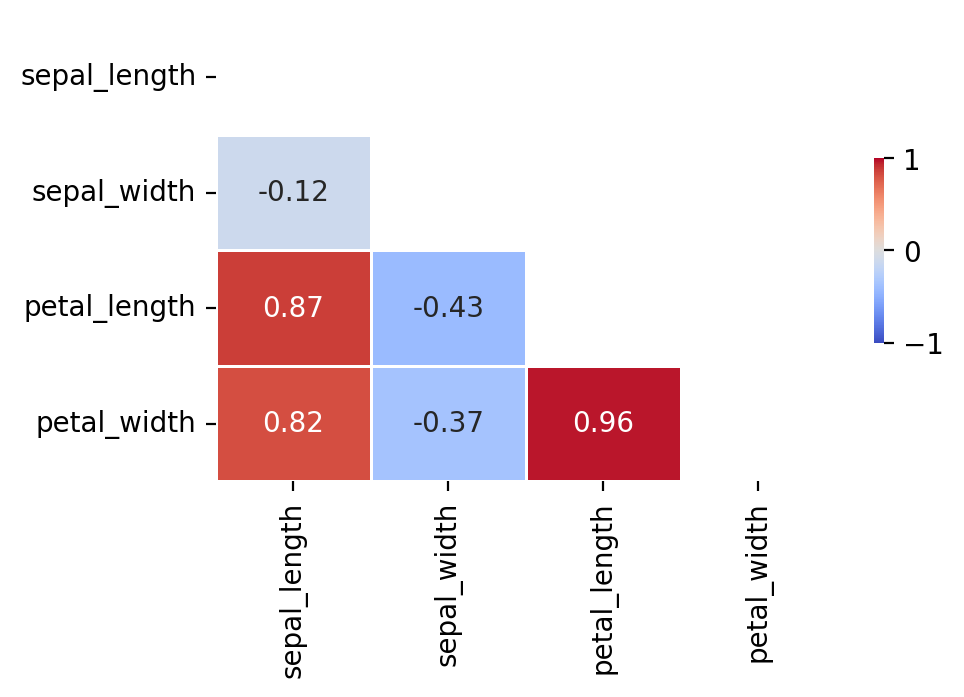

In [ ]:
sns.heatmap(corr, annot=True, cmap='coolwarm', mask=mask,
            vmin=-1, vmax=1, cbar_kws = {'shrink': .4 }, lw=1)

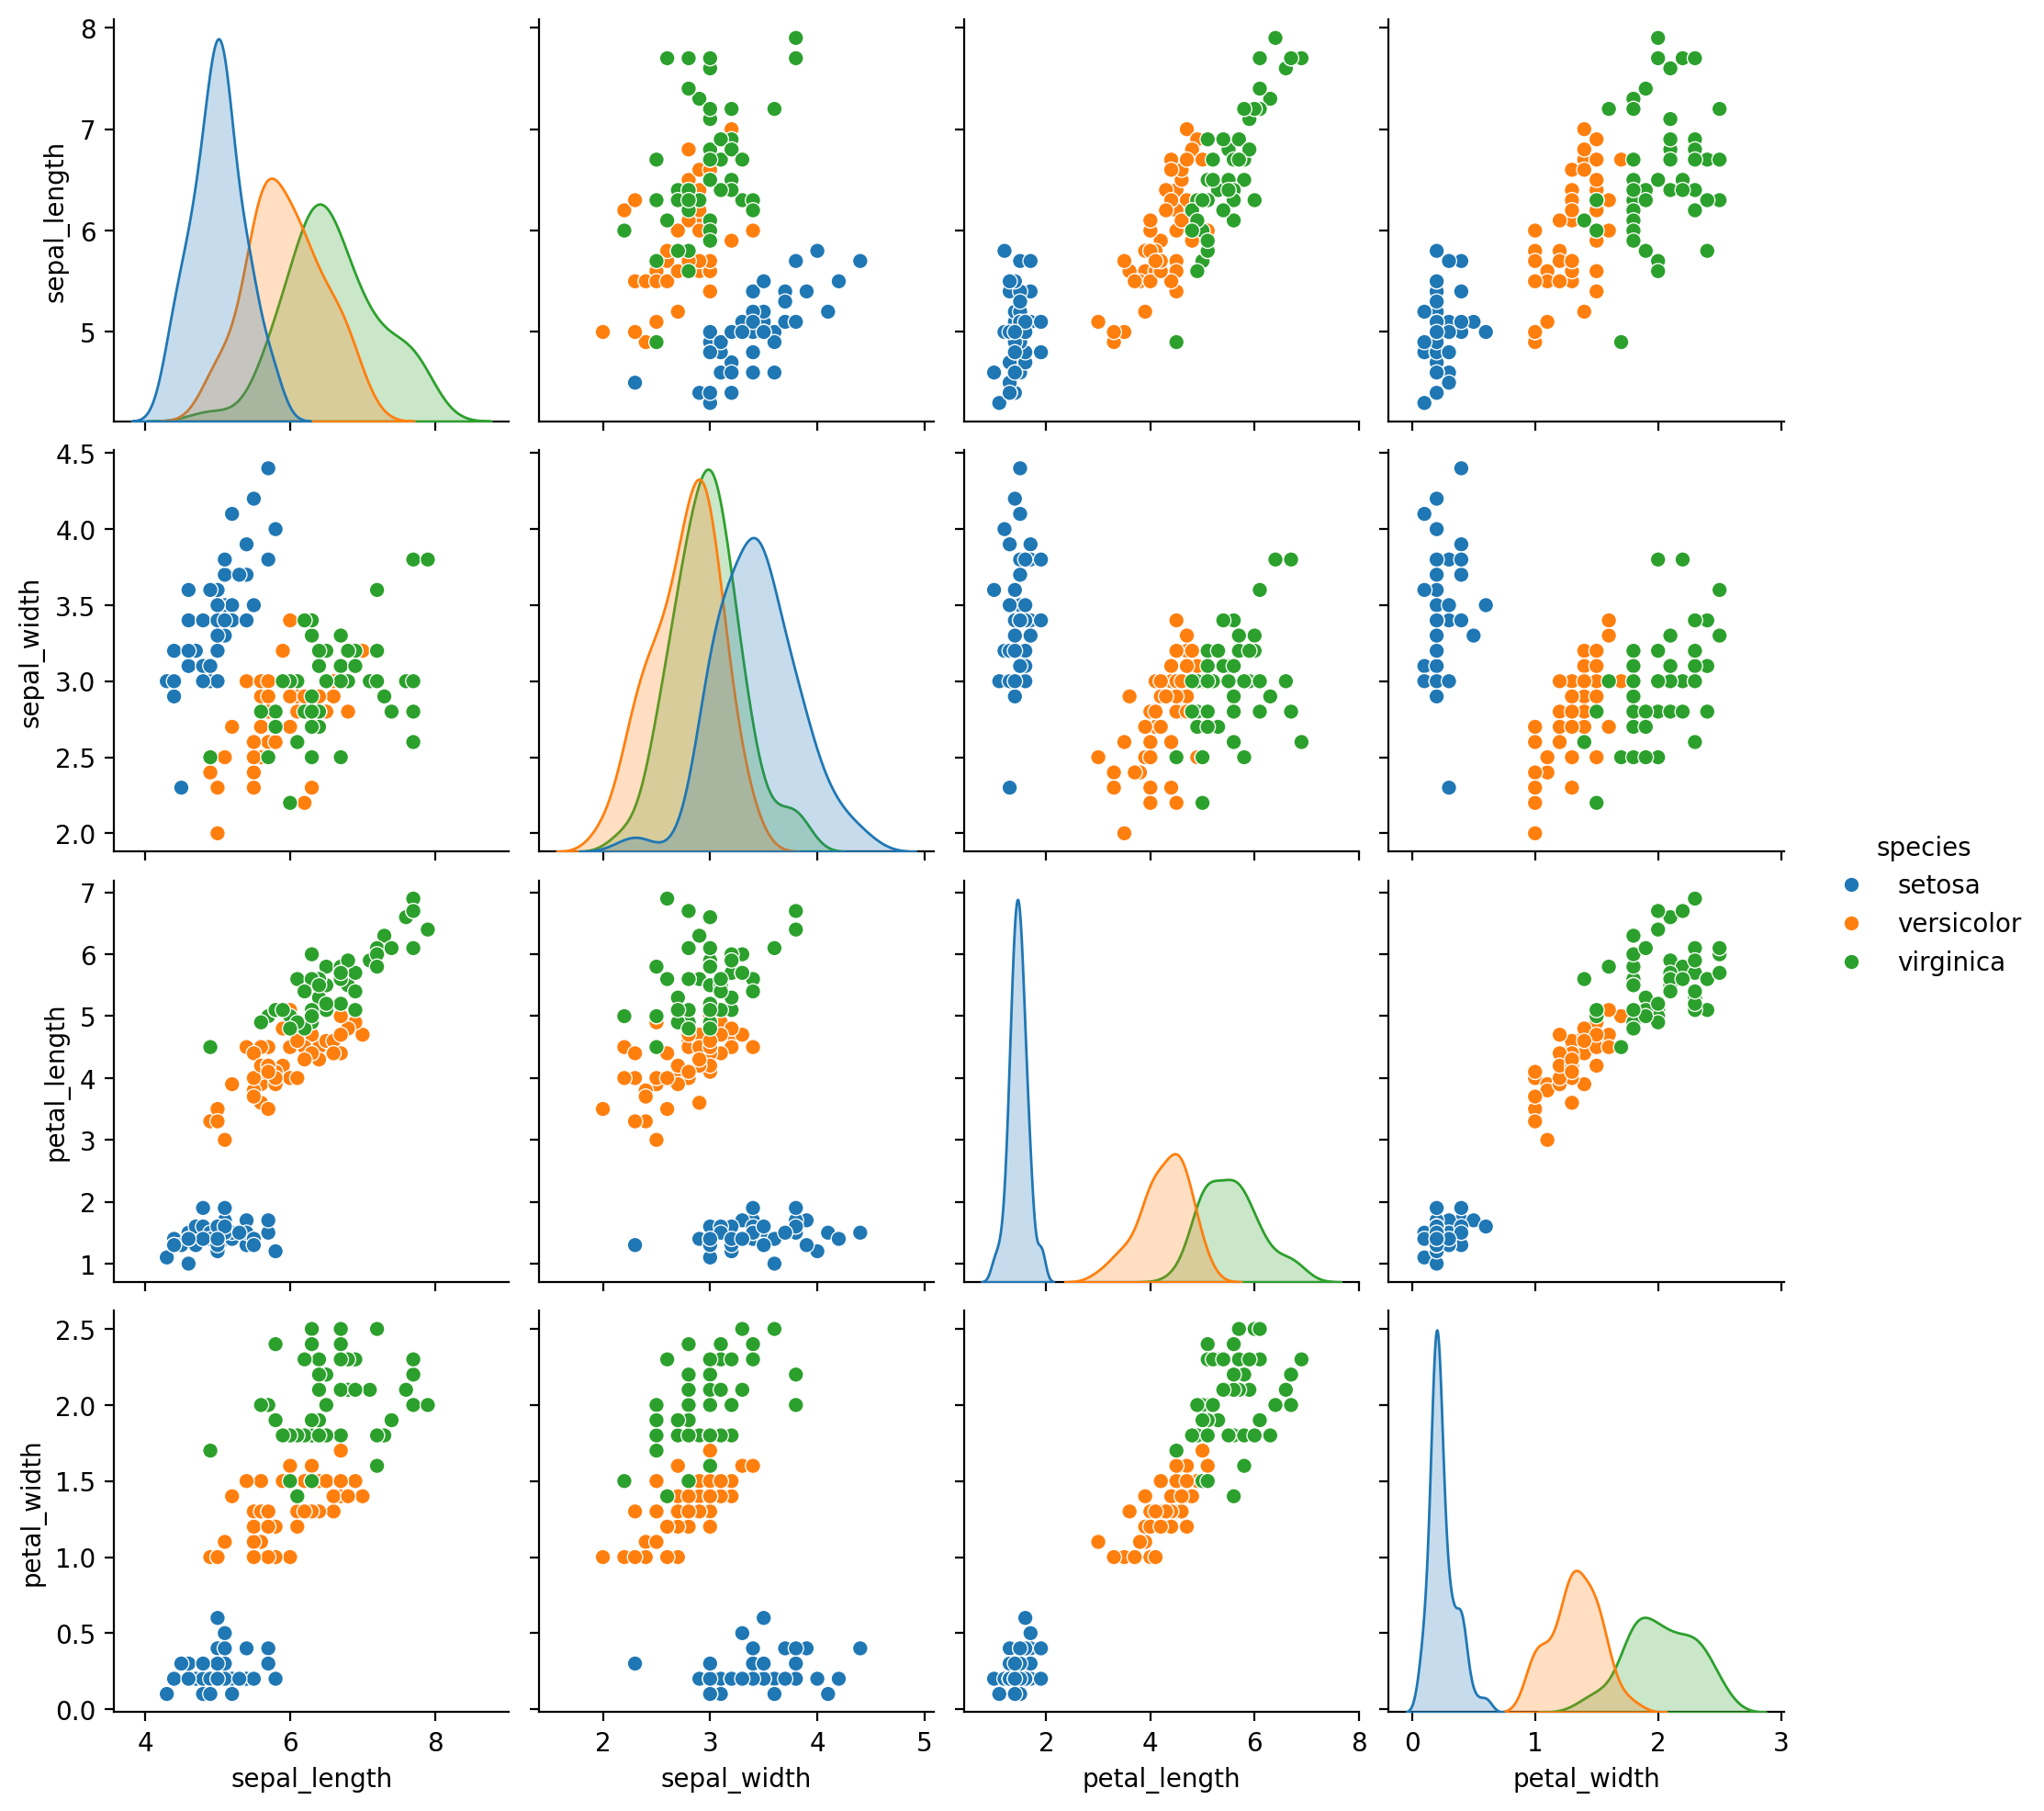

In [ ]:
sns.pairplot(iris, hue = 'species')
plt.show()

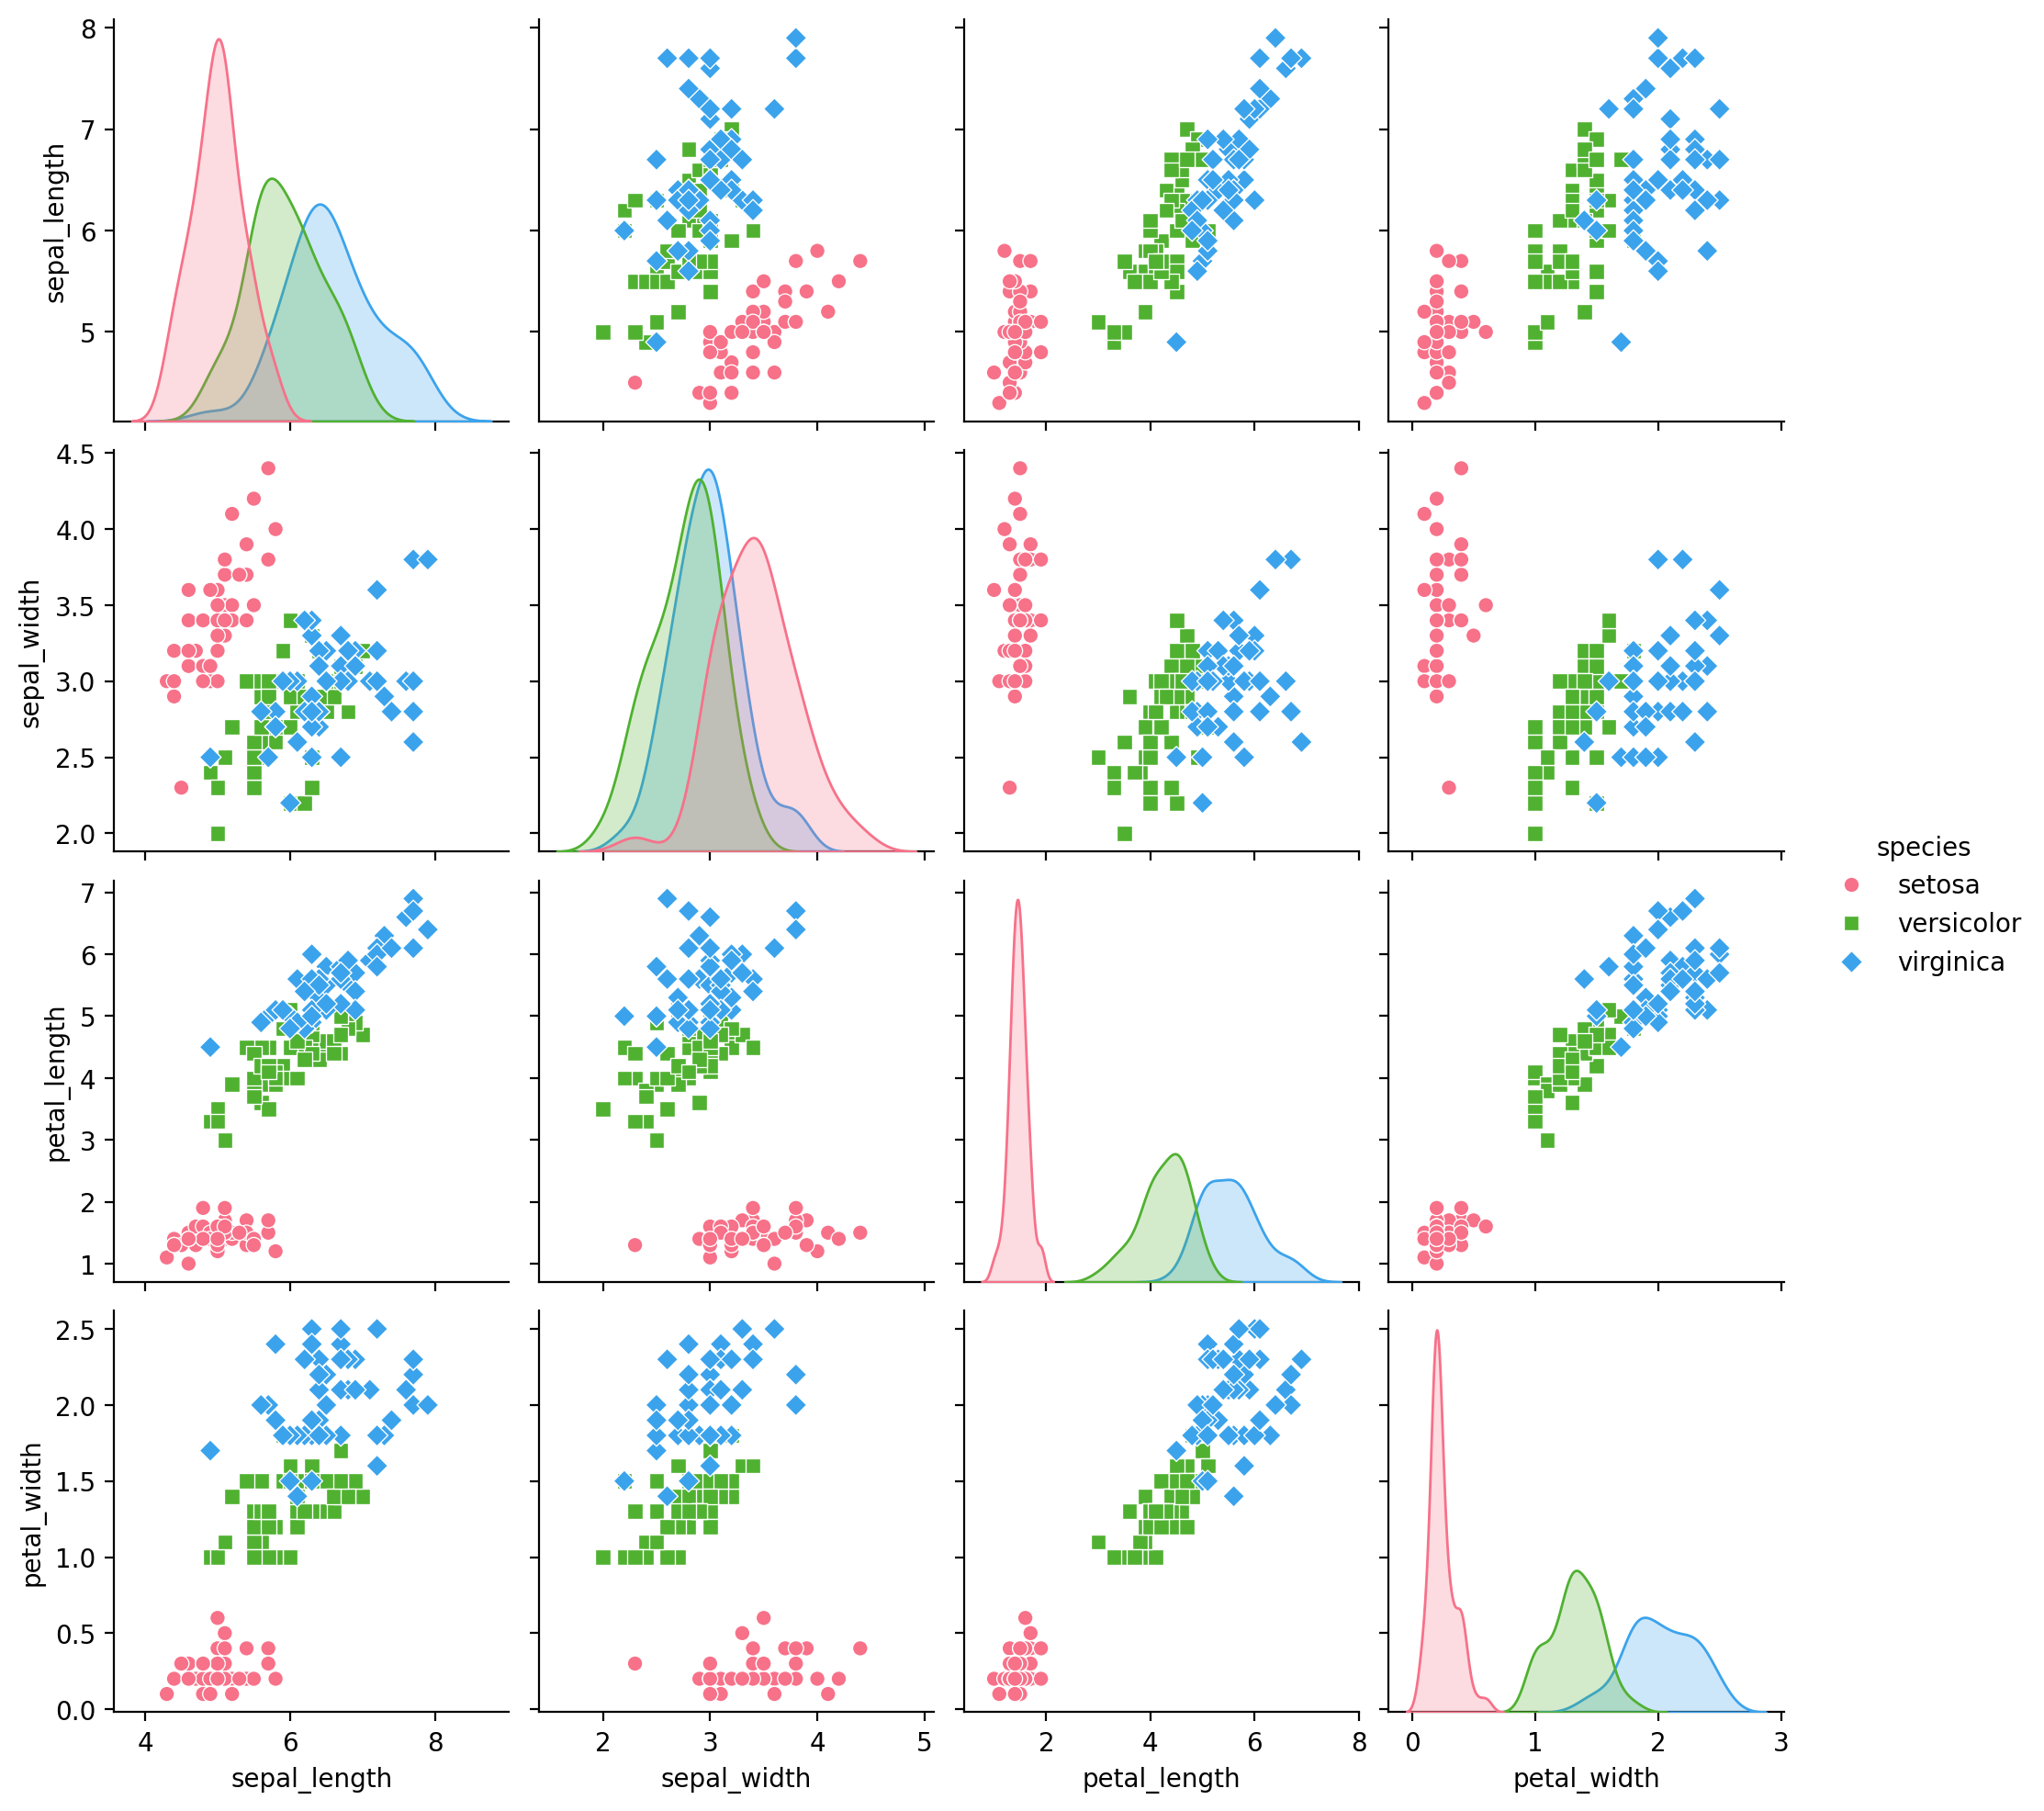

In [ ]:
sns.pairplot(iris, palette='husl', hue='species', markers=['o', 's', 'D'])
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'level', 'cloler'
  cset = contour_func(
/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'level', 'cloler'
  cset = contour_func(
/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'level', 'cloler'
  cset = contour_func(
/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'level', 'cloler'
  cset = contour_func(
/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'level', 'cloler'
  cset = contour_func(
/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'level', 

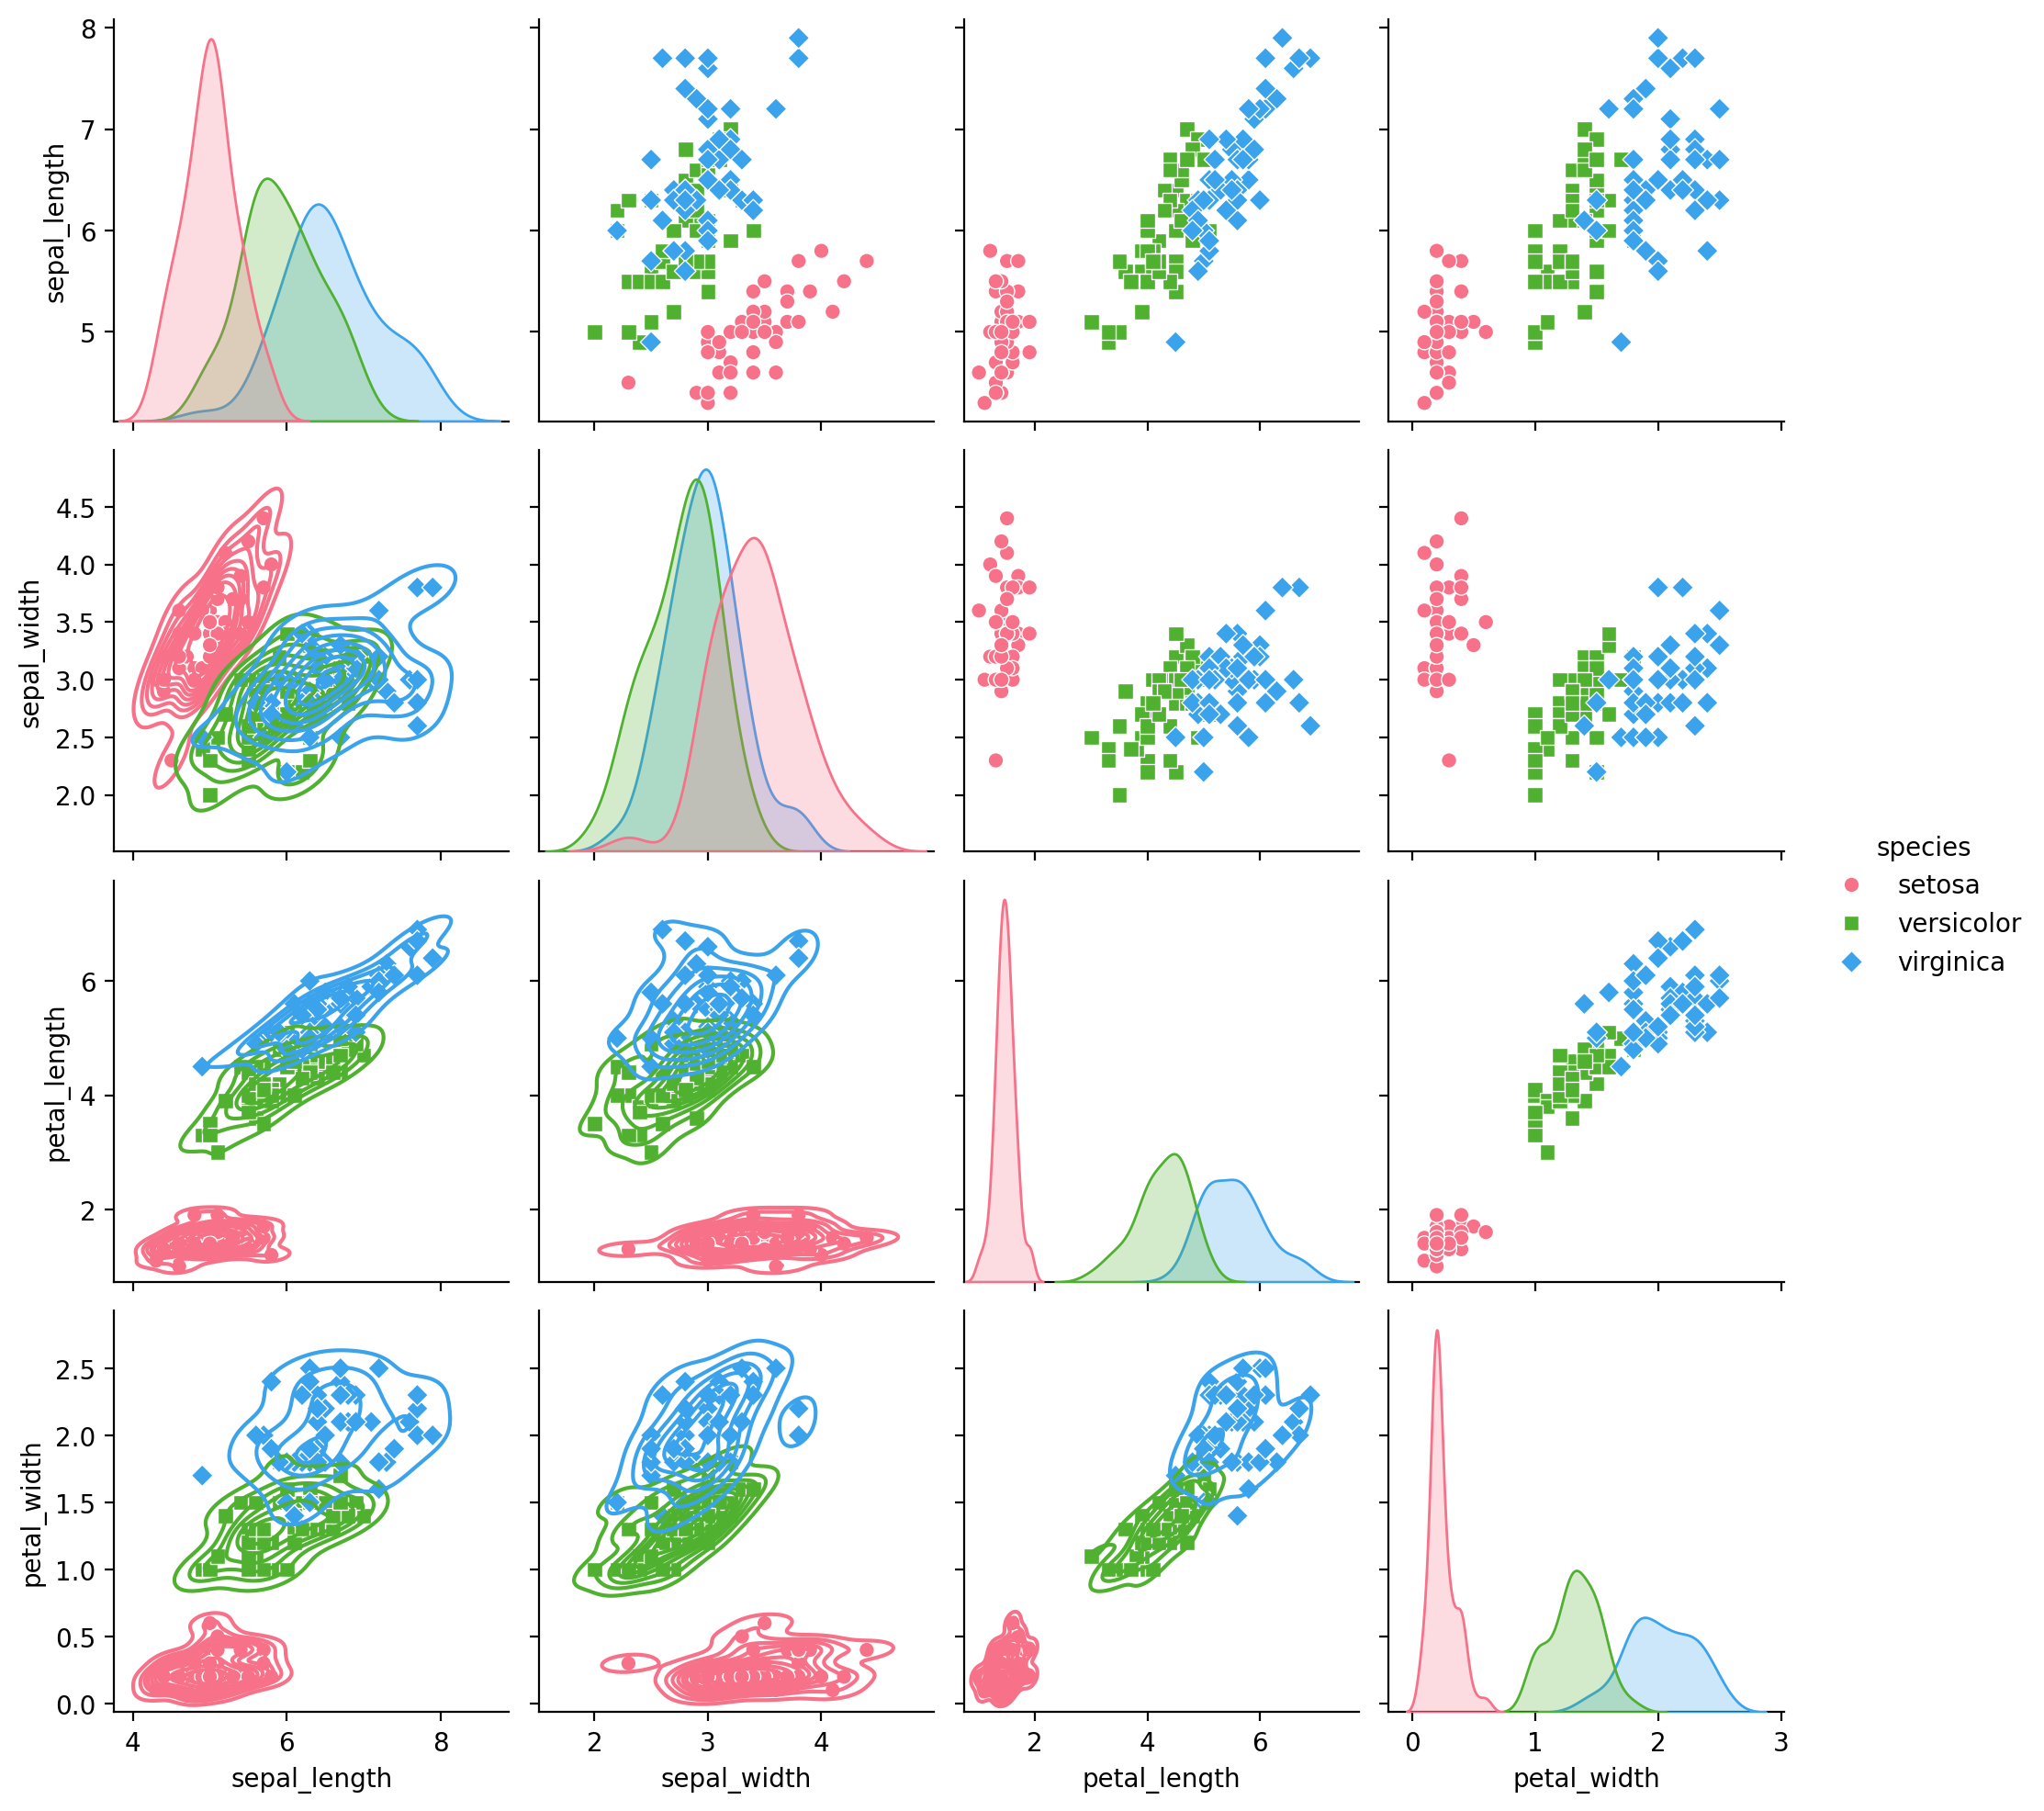

In [ ]:
g = sns.pairplot(iris, palette='husl', hue='species', markers=['o', 's', 'D'])
g.map_lower(sns.kdeplot, level=4, cloler = 2)

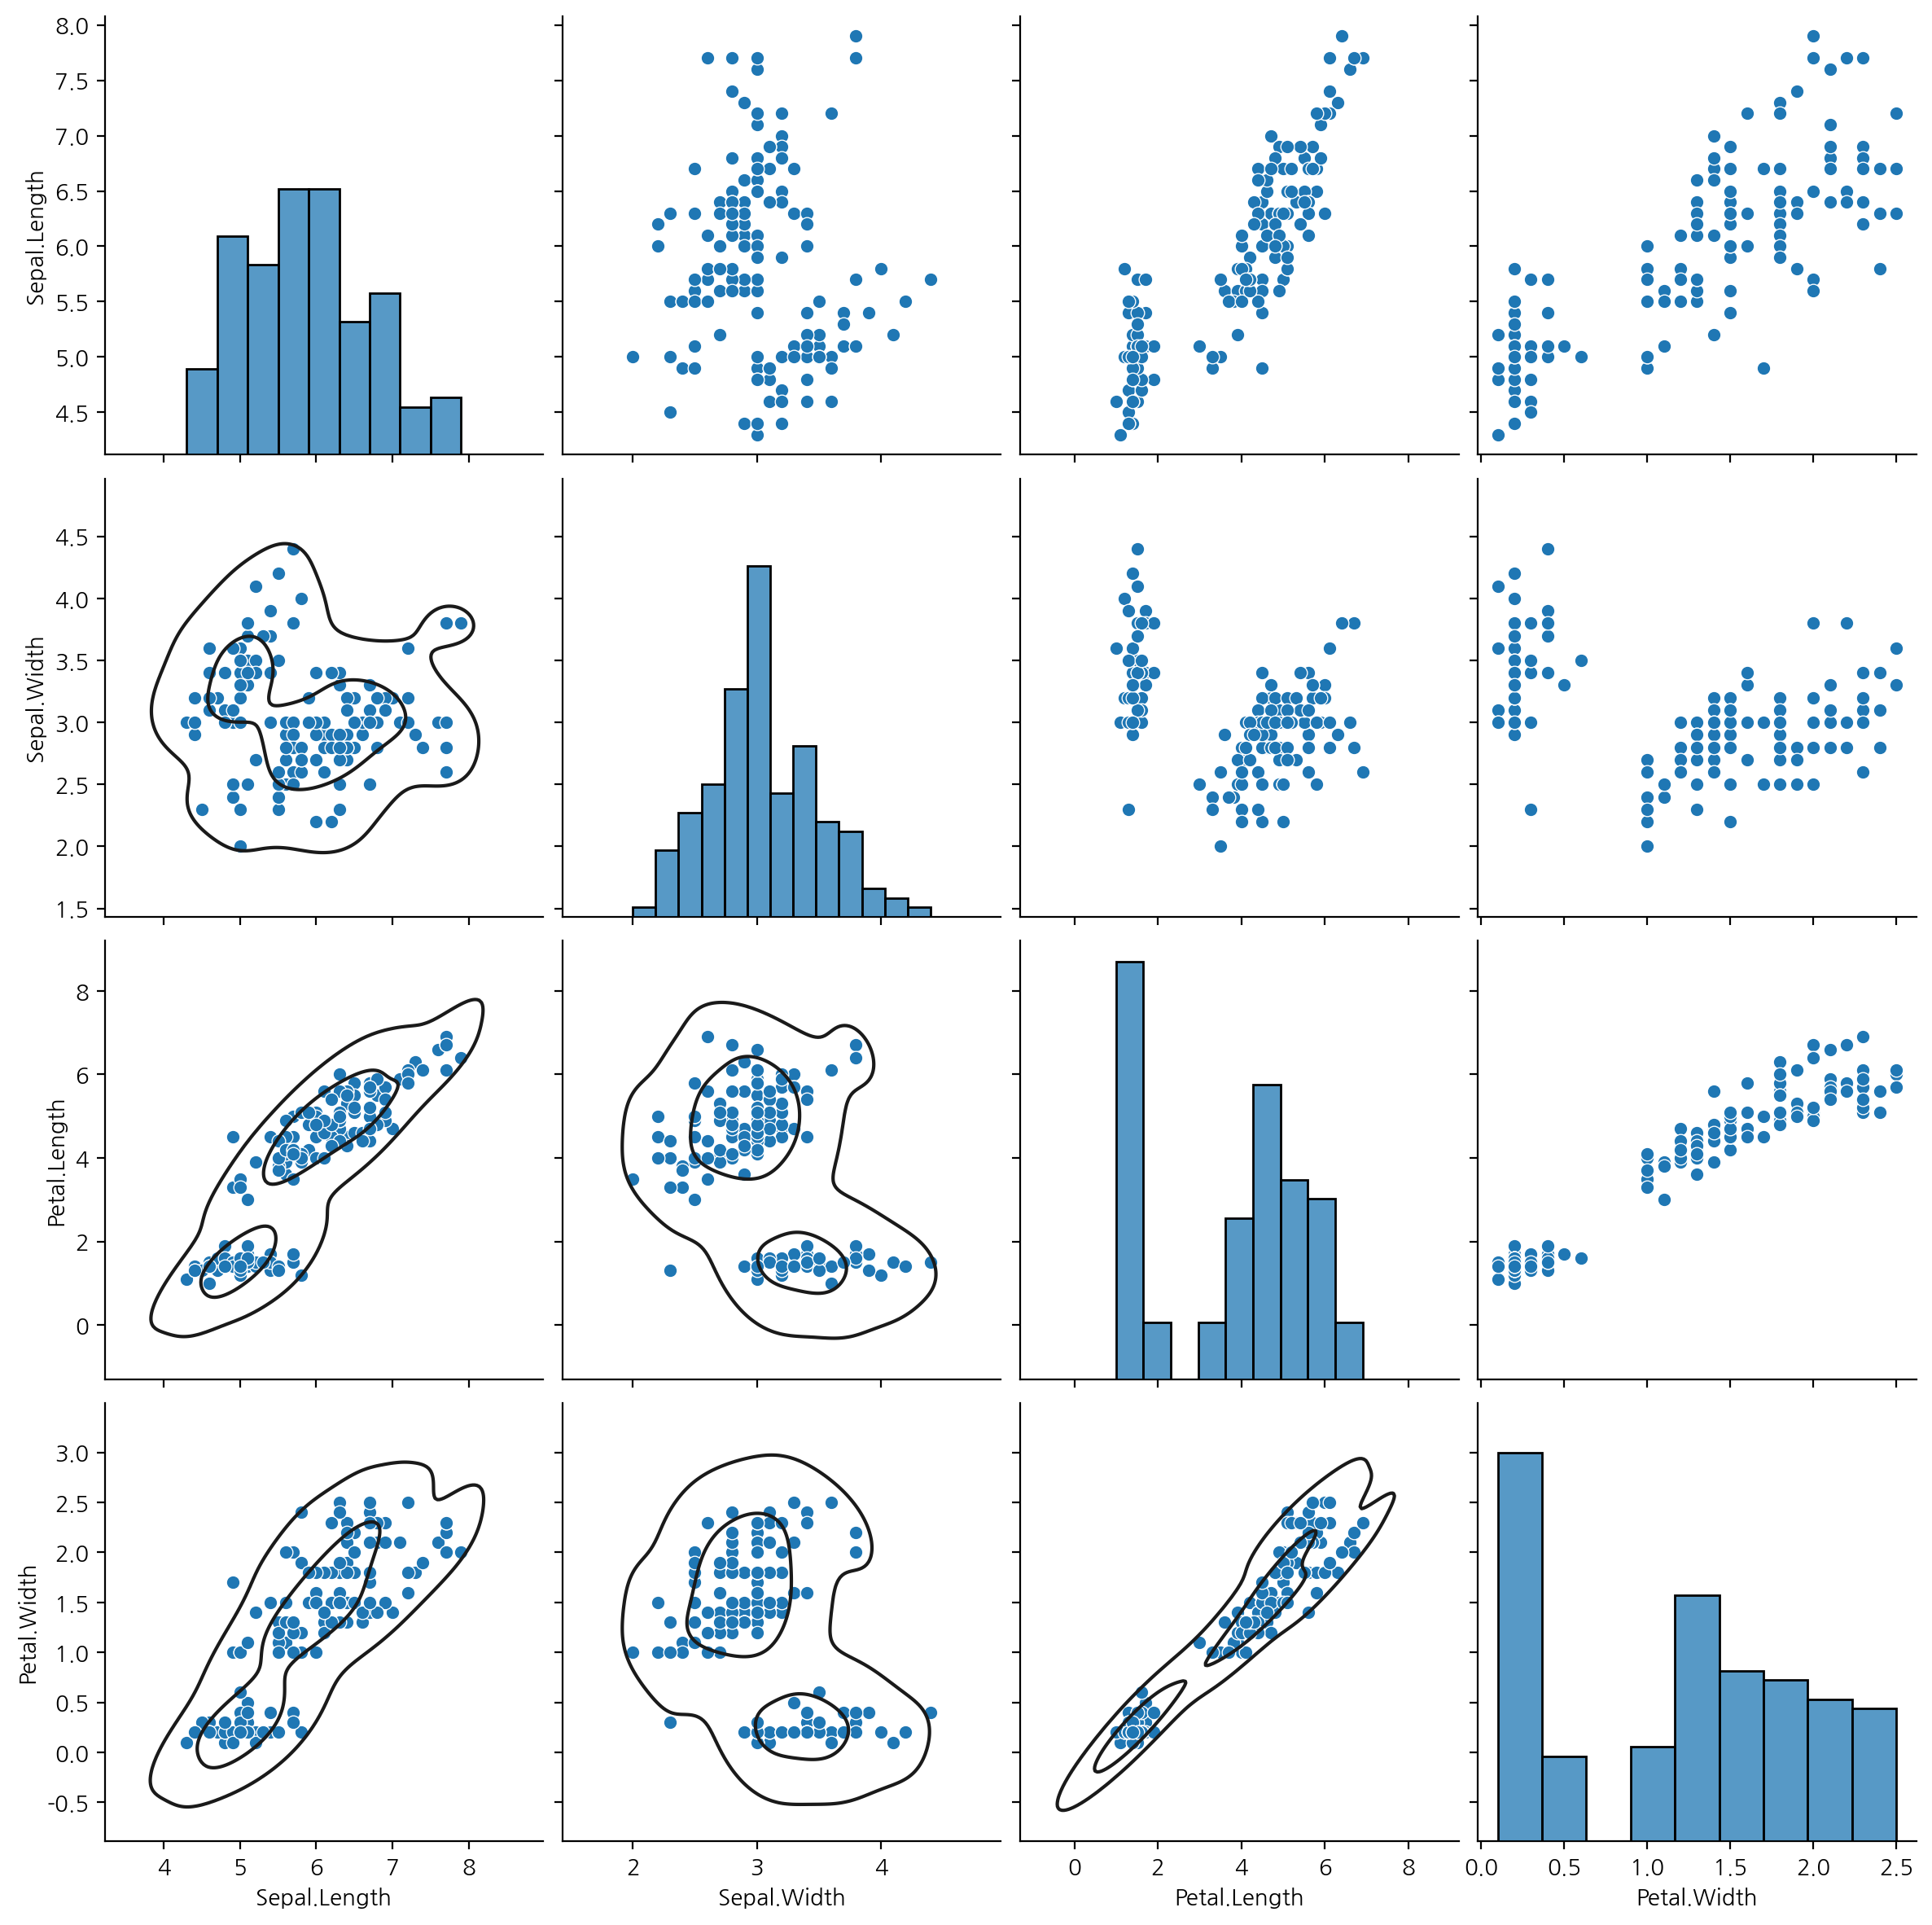

In [35]:
g = sns.pairplot(iris, height=3)
g.map_lower(sns.kdeplot, levels=3, color=".1")
plt.show()